# Анализ "стабильности" полей

**Дата: 21.08.2026**

----

#### Задача: 


#### Цели: 
- 
- 

----

## 1. Подготовка рабочего пространства

### Импорт библиотек

In [1]:
import re
import os
import numpy as np
import pandas as pd
from IPython.display import display
from openpyxl.utils import get_column_letter
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
import seaborn as sns
import textwrap

print('Готово')

Готово


### Загрузка и подготовка данных

In [2]:
# Список 
datasets = {
    'df_fields': 'data_input/fields.csv',
}

# Словарь для сохранения
data = {}

for name, path in datasets.items():
    print('-' * 50)
    print(f"Загрузка: {name}")
    
    df = pd.read_csv(path)
    
    print("Размер:", df.shape)
    print("Столбцы:", df.columns.tolist())
    
    data[name] = df

# Сохр. в перменные
df_fields = data['df_fields']


print('-' * 50)
print("\nДатасет загружен")

display(df_fields.head(5))

--------------------------------------------------
Загрузка: df_fields
Размер: (155510, 13)
Столбцы: ['field_id', 'field_name', 'division', 'area_ha', 'year', 'crop_id', 'variety', 'sowing_date', 'harvesting_date', 'productivity', 'expected_yield', 'is_active', 'crop_name']
--------------------------------------------------

Датасет загружен


,field_id,field_name,division,area_ha,year,crop_id,variety,sowing_date,harvesting_date,productivity,expected_yield,is_active,crop_name
0,2142,23-28-КНЛВ-057,Дивизион Север,133.0,2016,66.0,П 9578,2016-04-21,NaN,55.650000,NaN,True,Кукуруза на зерно
1,2142,23-28-КНЛВ-057,Дивизион Север,133.0,2017,52.0,"Амбадор РС1, Баграт ЭС, Курс ЭС, Морозко ЭС, Т...",2016-10-27,NaN,68.011666,NaN,True,Пшеница озимая
2,2142,23-28-КНЛВ-057,Дивизион Север,133.0,2018,30.0,Мадонна РС2,2018-04-08,NaN,27.390000,NaN,True,Горох
3,2142,23-28-КНЛВ-057,Дивизион Север,133.0,2019,52.0,Юбилейная 100 РС1,2018-09-23,NaN,57.770000,NaN,True,Пшеница озимая
4,2142,23-28-КНЛВ-057,Дивизион Север,133.0,2020,60.0,"Неро F-1, Неро F-1",2020-03-21,NaN,284.090000,NaN,True,Свекла сахарная


In [3]:
# ------------------------------------------------------
#размер 
print("Размер датасета:", df_fields.shape)

# ищем пропуски
print('\nПропусков:')
print(df_fields.isnull().sum())

# проверка на дубликаты
print('\nДубликатов:',df_fields.duplicated().sum())

print('\nКол-во значений')
print(df_fields.nunique())

print('\nОбщая информация:')
df_fields.info()

# описание данных
print('\nОписание данных')
df_fields.describe().round(2)

Размер датасета: (155510, 13)

Пропусков:
field_id                0
field_name              0
division                0
area_ha              1160
year                    0
crop_id             54010
variety             72520
sowing_date         73835
harvesting_date    144129
productivity        72088
expected_yield     154428
is_active               0
crop_name           54010
dtype: int64

Дубликатов: 0

Кол-во значений
field_id           15551
field_name         15547
division               8
area_ha             1511
year                  10
crop_id               99
variety             8176
sowing_date         1858
harvesting_date      254
productivity       28011
expected_yield         1
is_active              2
crop_name             99
dtype: int64

Общая информация:
<class 'pandas.DataFrame'>
RangeIndex: 155510 entries, 0 to 155509
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   field_id         15

,field_id,area_ha,year,crop_id,productivity,expected_yield
count,155510.00,154350.00,155510.00,101500.00,83422.00,1082.0
mean,22567.03,71.32,2020.50,51.32,74.20,0.0
std,9290.28,60.04,2.87,20.37,260.11,0.0
min,2142.00,0.03,2016.00,1.00,0.00,0.0
25%,16436.00,29.00,2018.00,52.00,27.42,0.0
50%,21196.00,64.00,2020.50,52.00,48.07,0.0
75%,26039.00,97.00,2023.00,55.00,65.05,0.0
max,61051.00,1535.66,2025.00,171.00,64540.00,0.0


**Ппромежуточный вывод:**
    
- Выброс в productivity (максимум 64 540 ц/га).
    - Предел урожайности большинства культур лежит в диапазоне 10–150 ц/га. Значение 64 540 - это явная ошибка ввода (например, в колонку попал валовый сбор в тоннах или килограммах вместо урожайности). Медиана при этом составляет 48.07 ц/га, а 75%-квантиль - 65.05 ц/га, что отражает нормальные распределение.

- Бесполезный признак expected_yield.
    - Из 155 510 строк заполнено всего 1 082 (99.3% пропусков), при этом все известные значения равны 0.0. Эту колонку можно сразу удалять.

- Пропуски в культурах и урожайности (crop_name и productivity)
    - В 54 010 строках (34.7%) отсутствует культура (crop_id / crop_name), а в 72 088 строках (46.4%) нет урожайности. Это ситуация, когда земля "отдыхает" или период, когда поле еще не было введено в оборот. Эти пропуски нужно будет разметить.

- Пропуски в площади area_ha (1 160 строк).


- Преобладание одной культуры.
    - crop_id = 52.0 попадает на квантили 25%, 50% и 75%. Это указывает на доминирующий вид посевов.

---

### Обработка

In [4]:
# очистка
df_clean = df_fields.copy()
df_clean["crop_name"] = (
    df_clean["crop_name"].fillna("Пар").astype(str).str.strip()
)
df_clean["division"] = df_clean["division"].astype(str).str.strip()
df_clean["year"] = pd.to_numeric(df_clean["year"], errors="coerce")

# Маркировка Пара (строка остаётся, продуктивность обнуляется)
is_fallow = df_clean["crop_name"].str.contains(
    "Пар|Не засеяно", case=False, na=False
)
df_clean.loc[is_fallow, "productivity"] = np.nan

# Фильтрация 1% верхних выбросов по 99-му квантилю
q99 = df_clean.groupby(["crop_name", "year"])["productivity"].transform(
    lambda x: x.quantile(0.99)
)
df_clean.loc[df_clean["productivity"] > q99, "productivity"] = np.nan

# Расчет относительного индекса продуктивности (yield_ratio)
div_median = df_clean.groupby(["crop_name", "division", "year"])[
    "productivity"
].transform("median")
df_clean["yield_ratio"] = df_clean["productivity"] / div_median

# сортировка и расчет предшественников
df_clean = df_clean.sort_values(by=["field_id", "year"]).reset_index(drop=True)
df_clean["prev_crop"] = df_clean.groupby("field_id")["crop_name"].shift(1)
df_clean["prev_year"] = df_clean.groupby("field_id")["year"].shift(1)

is_consecutive = (df_clean["year"] - df_clean["prev_year"]) == 1
df_clean.loc[~is_consecutive, "prev_crop"] = np.nan

# Расчет стабильности поля по всем доступным yield_ratio
df_clean["stability"] = (
    df_clean.groupby("field_id")["yield_ratio"].transform("std").fillna(0)
)

# Удаление служебного столбца
df_clean = df_clean.drop(columns=["prev_year"])

# Сохранение
output_dir = "df_clean_stability"
os.makedirs(output_dir, exist_ok=True)

# Сохранение CSV
csv_path = os.path.join(output_dir, "clean_data_stability.csv")
df_clean.to_csv(csv_path, index=False, encoding="utf-8-sig")

# Сохранение Excel с автонастройкой ширины колонок
xlsx_path = os.path.join(output_dir, "clean_data_stability.xlsx")
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    df_clean.to_excel(writer, sheet_name="Очищенные данные", index=False)
    worksheet = writer.sheets["Очищенные данные"]

    for col_idx, col_name in enumerate(df_clean.columns, 1):
        col_letter = get_column_letter(col_idx)
        max_len = df_clean[col_name].astype(str).str.len().max()
        max_len = max(max_len, len(col_name))
        worksheet.column_dimensions[col_letter].width = min(max_len + 2, 50)

print(f"Данные успешно обработаны и сохранены в папку '{output_dir}'")
print(f"Всего строк в итоговом датасете (включая пар): {len(df_clean)}")
print(f"Уникальных полей: {df_clean['field_id'].nunique()}")

Данные успешно обработаны и сохранены в папку 'df_clean_stability'
Всего строк в итоговом датасете (включая пар): 155510
Уникальных полей: 15551


**Промежуточный вывод:**
    
- Убраны лишние пробелы, годы приведены к числовому формату, а незаполненные названия культур помечены как "Пар".

- Для полей со статусом "Пар" и "Не засеяно" значение урожайности сбрасывается, сохраняя сами записи в истории поля.

- Для каждой пары [Культура + Год] отсечен 1% верхних нереалистичных аномалий и опечаток ввода по 99-му квантилю.

- Рассчитан относительный индекс продуктивности: $$\text{yield_ratio} = \frac{\text{productivity}}{\text{div_median}}$$где $\text{div_median}$ - локальная медиана группы [Культура + Дивизион + Год]. Это избавило от влияния погодных условий конкретного сезона, разницы в биологической урожайности культур и климатических особенностей дивизионов.



- Севооборот (prev_crop): определяется культура-предшественник с проверкой непрерывности лет. Если между записями поля есть пропуск (year - prev_year > 1), предшественник сбрасывается.

- Стабильность (stability): вычисляется стандартное отклонение индекса yield_ratio по каждому полю за все годы.



-----

## 2. Подготовка данных 

---

### Описание 

#### 1. Формула расчета

##### 1.1. Базовая норма поля ($\text{median_yr}$)

Для определения естественного потенциала поля используется медиана индекса урожайности (yield_ratio) за весь период его использования:

$$
\text{median_yr} = \text{Median}(\text{yield_ratio}_1, \text{yield_ratio}_2, \dots, \text{yield_ratio}_n)
$$

**Как читается:** Медиана берется вместо среднего арифметического, чтобы разовые аномальные провалы или рекордные урожаи не искажали представление о нормальной продуктивности поля.

##### 1.2. Относительное отклонение ($\text{dev_pct}$)

Показывает процентное смещение результата конкретного года от медианной нормы поля:

$$
\text{dev_pct} = \left( \frac{\text{yield_ratio} - \text{median_yr}}{\text{median_yr}} \right) \times 100\%
$$

**Как читается:** На сколько процентов фактический индекс урожайности в текущем году отклонился от типичного уровня этого поля.

* Положительное значение - урожай выше нормы.
* Отрицательное значение - урожай ниже нормы.

##### 1.3. Пороговая классификация ($\text{anomaly_type}$)

Аномалией считается событие, выходящее за рамки в $\pm 25\%$:

$$
\text{anomaly_type} = 
\begin{cases} 
\text{"Провал (-)"}, & \text{если } \text{dev_pct} \le -25.0\% \\
\text{"Всплеск (+)"}, & \text{если } \text{dev_pct} \ge +25.0\% \\
\text{"Норма"}, & \text{если } -25.0\% < \text{dev_pct} < +25.0\% 
\end{cases}
$$

---

#### 2. Структура  Excel (`field_anomalies.xlsx`)

* `field_id` / `field_name` - идентификатор и наименование поля.
* `division` - подразделение/филиал.
* `year` / `crop_name` - год и высеваемая культура.
* `prev_crop` - культура предшественник.
* `productivity` - фактическая урожайность (ц/га).
* `yield_ratio` - фактический индекс урожайности.
* `median_yr` - норма поля (медианный индекс).
* `dev_pct` - процент отклонения от нормы.
* `anomaly_type` - характер аномалии (Провал (-) или Всплеск (+)).


----

### Работа с данными

In [5]:
# 1. Настройка путей и загрузка данных
OUTPUT_DIR = "field_stability"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_excel = pd.read_excel("data_output/fields_clustered_all.xlsx")
df_clean = pd.read_csv("df_clean_stability/clean_data_stability.csv")

# Приведение типов
df_clean["field_id"] = df_clean["field_id"].astype(str).str.strip()
df_excel["ID поля"] = df_excel["ID поля"].astype(str).str.strip()

# 2. Фильтрация только стабильных полей (история >= 3 лет)
stable_fields = df_excel[
    (df_excel["Категория стабильности"] == "Стабильное")
    & (df_excel["Лет в обороте"] >= 3)
].copy()

df_merged = df_clean[
    df_clean["field_id"].isin(stable_fields["ID поля"])
].copy()

# 3. Расчет медиан и отклонений
field_stats = (
    df_merged.groupby("field_id")["yield_ratio"]
    .agg(median_yr="median", std_yr="std")
    .reset_index()
)

df_merged = df_merged.merge(field_stats, on="field_id", how="left")

df_merged["diff_yield_ratio"] = df_merged["yield_ratio"] - df_merged["median_yr"]
df_merged["dev_pct"] = (df_merged["diff_yield_ratio"] / df_merged["median_yr"]) * 100

# 4. Детекция аномалий
THRESHOLD = 25.0

is_par = df_merged["crop_name"].str.contains("Пар|Не засеяно", case=False, na=False)
is_missing = df_merged["productivity"].isna() & ~is_par

conditions = [
    is_par,                             # Земля отдыхала
    is_missing,                         # Данные отсутствуют
    df_merged["dev_pct"] <= -THRESHOLD,  # Провал
    df_merged["dev_pct"] >= THRESHOLD,   # Всплеск
]

choices = ["Отдых (Пар)", "Нет данных", "Провал (-)", "Всплеск (+)"]

df_merged["anomaly_type"] = np.select(conditions, choices, default="Норма")
df_merged["is_anomaly"] = df_merged["anomaly_type"].isin(["Провал (-)", "Всплеск (+)"])

# 5. Формирование детального реестра аномалий
anomalies_df = df_merged[df_merged["is_anomaly"]].copy()
anomalies_df["abs_dev_pct"] = anomalies_df["dev_pct"].abs()
anomalies_df = anomalies_df.sort_values(by="abs_dev_pct", ascending=False)

output_cols = [
    "field_id",
    "field_name",
    "division",
    "year",
    "crop_name",
    "prev_crop",
    "productivity",
    "yield_ratio",
    "median_yr",
    "dev_pct",
    "anomaly_type",
]

result_details = anomalies_df[output_cols].copy()
result_details["dev_pct"] = result_details["dev_pct"].round(1)
result_details["yield_ratio"] = result_details["yield_ratio"].round(2)
result_details["median_yr"] = result_details["median_yr"].round(2)
result_details["productivity"] = result_details["productivity"].round(1)

# 6. Сохранение результатов (одна вкладка)
csv_path = os.path.join(OUTPUT_DIR, "field_anomaly_.csv")
excel_path = os.path.join(OUTPUT_DIR, "field_anomalies.xlsx")

result_details.to_csv(csv_path, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    result_details.to_excel(
        writer, sheet_name="Детальные_аномалии", index=False
    )

    # Автонастройка ширины колонок для единственного листа
    worksheet = writer.sheets["Детальные_аномалии"]
    for col in worksheet.columns:
        max_len = max(len(str(cell.value or "")) for cell in col)
        col_letter = get_column_letter(col[0].column)
        worksheet.column_dimensions[col_letter].width = max(max_len + 3, 12)

print(f"Файлы сохранены в '{os.path.abspath(OUTPUT_DIR)}':")
print(f"CSV: {csv_path}")
print(f"Excel: {excel_path}")

Файлы сохранены в 'C:\Users\Admin\fields_clusters_final\field_stability':
CSV: field_stability\field_anomaly_.csv
Excel: field_stability\field_anomalies.xlsx


### Карточка поля

In [6]:
# Поля, у которых есть аномалии (для проверки "взлетов" и "провалов")
ids_with_anomalies = (
    df_merged[df_merged["is_anomaly"]]["field_id"].unique()[:5].tolist()
)
print("Примеры ID полей с аномалиями:", ids_with_anomalies)

# Поля, которые работали стабильно (без аномалий)
ids_perfect = (
    set(df_merged["field_id"].unique())
    - set(df_merged[df_merged["is_anomaly"]]["field_id"].unique())
)
print("Примеры ID полей без аномалий:", list(ids_perfect)[:5])

Примеры ID полей с аномалиями: ['6294', '7045', '7131', '7140', '12360']
Примеры ID полей без аномалий: ['16018', '24794', '27251', '14441', '12739']


In [7]:
def show_field_card(field_id):
    """Выводит полную историю поля со статусом лет"""
    field_id_str = str(field_id).strip()

    field_data = df_merged[
        df_merged["field_id"].astype(str) == field_id_str
    ].copy()

    if field_data.empty:
        print(f"Поле с id {field_id} не найдено.")
        return

    info = field_data.iloc[0]
    excel_meta_df = df_excel[df_excel["ID поля"].astype(str) == field_id_str]

    if excel_meta_df.empty:
        print(f"Данные для поля с id {field_id} не найдены в excel.")
        return

    excel_meta = excel_meta_df.iloc[0]

    print(f"Карточка поля: {info['field_name']} (id: {field_id})")
    print(
        f"Дивизион: {info['division']} | Площадь: {excel_meta.get('Площадь поля (га)', 'н/д')} га"
    )
    print(
        f"Статус в excel: {excel_meta.get('Категория урожайности (Правила)', 'н/д')} | {excel_meta.get('Категория стабильности', 'н/д')}"
    )
    print(
        f"Медианный индекс урожайности: {info['median_yr']:.3f} | Разброс (std): {info['std_yr']:.3f}"
    )
    print("-" * 50)

    cols = [
        "year",
        "crop_name",
        "productivity",
        "yield_ratio",
        "dev_pct",
        "anomaly_type",
    ]
    history = field_data[cols].copy()

    # Статусы
    status_map = {
        "Отдых (Пар)": "отдых",
        "Нет данных": "нет данных",
        "Норма": "норма",
        "Провал (-)": "аномалия",
        "Всплеск (+)": "аномалия",
    }
    history["Статус"] = history["anomaly_type"].map(status_map)

    history.columns = [
        "Год",
        "Культура",
        "Урожайность (ц/га)",
        "Индекс урожайности",
        "Отклонение (%)",
        "Тип отклонения",
        "Статус",
    ]

    history["Урожайность (ц/га)"] = history["Урожайность (ц/га)"].round(1)
    history["Индекс урожайности"] = history["Индекс урожайности"].round(3)
    history["Отклонение (%)"] = history["Отклонение (%)"].round(1)

    display(history)

    anomalies = field_data[field_data["is_anomaly"]]
    if len(anomalies) > 0:
        print(
            f"\nОбнаружено аномалий: {len(anomalies)} год(а) из {len(history)}."
        )
        for _, row in anomalies.iterrows():
            direction = "взлет" if row["dev_pct"] > 0 else "провал"
            print(
                f"   - {int(row['year'])} ({row['crop_name']}): {direction} ({row['dev_pct']:+.1f}%)"
            )
    else:
        print("\nАномалий не обнаружено.")
    print("\n")

# Пример вызова 
show_field_card(12360)

Карточка поля: 26-03-ДИВН-127 (id: 12360)
Дивизион: Дивизион Новокубанский | Площадь: 78.0 га
Статус в excel: Среднее | Стабильное
Медианный индекс урожайности: 1.031 | Разброс (std): 0.181
--------------------------------------------------


,Год,Культура,Урожайность (ц/га),Индекс урожайности,Отклонение (%),Тип отклонения,Статус
70,2016,Пшеница озимая,66.0,1.421,37.8,Всплеск (+),аномалия
71,2017,Пшеница озимая,49.8,0.927,-10.0,Норма,норма
72,2018,Пар,NaN,NaN,NaN,Отдых (Пар),отдых
73,2019,Пшеница озимая,50.6,0.945,-8.4,Норма,норма
74,2020,Пар,NaN,NaN,NaN,Отдых (Пар),отдых
75,2021,Пшеница озимая,54.0,1.059,2.7,Норма,норма
76,2022,Пар,NaN,NaN,NaN,Отдых (Пар),отдых
77,2023,Пшеница озимая,49.9,1.051,2.0,Норма,норма
78,2024,Пар,NaN,NaN,NaN,Отдых (Пар),отдых
79,2025,Пшеница озимая,64.7,1.011,-2.0,Норма,норма



Обнаружено аномалий: 1 год(а) из 10.
   - 2016 (Пшеница озимая): взлет (+37.8%)




### Обьяснение

Если пошагово то так:

#### 1. Индекс года ($\text{yield_ratio}$)
Урожайность поля делится на медиану дивизиона по той же культуре и за тот же год.

* **2016 год:** $66.0 / 46.44 = \mathbf{1.421}$ (поле сработало на $+42.1\%$ лучше "нормы").
* **2025 год:** $64.7 / 64.0 = \mathbf{1.011}$ (поле сработало на уровне "нормы").

#### 2. Норма поля ($\text{median_yr}$)
Рассчитывается как медиана всех $\text{yield_ratio}$ поля за его активные годы (тут **1.031**).

#### 3. Отклонение ($\text{dev_pct}$)
Сравнивает результат конкретного года с нормой поля:

$$
\text{dev_pct} = \left( \frac{\text{yield_ratio} - \text{median_yr}}{\text{median_yr}} \right) \times 100\%
$$

* **2016 год:**  
  $$
  \frac{1.421 - 1.031}{1.031} \times 100\% = \mathbf{+37.8\%}
  $$  
  Значение выше порога $+25\%$, поэтому пишется **«Всплеск (+)»** (аномалия).

* **2025 год:**  
  $$
  \frac{1.011 - 1.031}{1.031} \times 100\% = \mathbf{-2.0\%}
  $$  
  Значение находится внутри интервала $\pm 25\%$, поэтомуэ это **«Норма»**.


#### И что в итоге:

* **В 2016 году** поле "выделилось" на фоне района и сработало **аномально лучше** своей нормы.
* **В 2025 году** при тех же абсолютных цифрах урожайность была высокой у всего района, поэтому поле отработало в рамках своей **нормальной эффективности**.

---

## Исследование данных

### Динамика урожайности по культурам и дивизионам

#### Кол-во культур

In [8]:
pd.set_option("display.max_rows", None)

print("Культуры")
print(df_merged["crop_name"].value_counts(dropna=False))

Культуры
crop_name
Пшеница озимая                                        15526
Пар                                                    5495
Подсолнечник масличный                                 3272
Свекла сахарная                                        2413
Соя                                                    2220
Кукуруза на зерно                                      2115
Ячмень озимый                                          1487
Рис                                                    1370
Многолетние травы прошлых лет                          1282
Кукуруза на силос и зеленый корм                       1223
Горох                                                   764
АМП                                                     611
Пшеница яровая мягкая                                   474
Подсолнечник СПК (крупноплодный)                        461
Многолетние травы текущего года                         430
Рапс озимый                                             304
Лен масличный        

#### Код визуализаций

In [9]:
CHARTS_DIR = "dynamics"
os.makedirs(CHARTS_DIR, exist_ok=True)
# Список целевых культур
target_crops = [
    "Пшеница озимая",
    "Подсолнечник масличный",
    "Пшеница яровая мягкая",
    "Кукуруза на зерно",
]

# убираем Пар, NaN и оставляем только целевые культуры
df_active = df_merged[
    df_merged["productivity"].notna()
    & ~df_merged["crop_name"].str.contains("Пар", na=False)
    & df_merged["crop_name"].isin(target_crops)
].copy()

# приводим год к целочисленному типу
df_active["year"] = df_active["year"].astype(int)

# агрегация медианы урожайности
macro_trends = (
    df_active.groupby(["division", "crop_name", "year"])["productivity"]
    .median()
    .reset_index()
)

# Генерация графиков
chart_count = 0

for division in macro_trends["division"].unique():
    div_data = macro_trends[macro_trends["division"] == division]

    for crop in div_data["crop_name"].unique():
        subset = div_data[div_data["crop_name"] == crop].sort_values("year")

        # Строим график только если есть хотя бы 3 года истории
        if len(subset) < 3:
            continue

        fig, ax = plt.subplots(figsize=(10, 4.5))
        ax.plot(
            subset["year"],
            subset["productivity"],
            marker="o",
            color="#1f77b4",
            linewidth=2.5,
        )

        ax.set_title(
            f"Динамика: '{crop}'\n{division}",
            fontsize=11,
            fontweight="bold",
        )
        ax.set_xlabel("Год")
        ax.set_ylabel("Медиана урожайности (ц/га)")
        ax.grid(True, linestyle="--", alpha=0.5)

        # Ограничение оси X только целыми годами без дробей
        ax.set_xticks(subset["year"].unique())
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%d"))

        # Вывод чисел над точками
        for _, row in subset.iterrows():
            ax.annotate(
                f"{row['productivity']:.1f}",
                (row["year"], row["productivity"]),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontweight="bold",
            )

        safe_div = re.sub(r'[\\/*?:"<>|]', "", str(division)).replace(" ", "_")
        safe_crop = re.sub(r'[\\/*?:"<>|]', "", str(crop)).replace(" ", "_")
        filename = f"{safe_div}__{safe_crop}.png"

        plt.tight_layout()
        plt.savefig(os.path.join(CHARTS_DIR, filename), dpi=150)
        plt.close(fig)
        chart_count += 1

print(f"Генерация завершена. Сформировано графиков: {chart_count}")

Генерация завершена. Сформировано графиков: 19


---
#### Пример

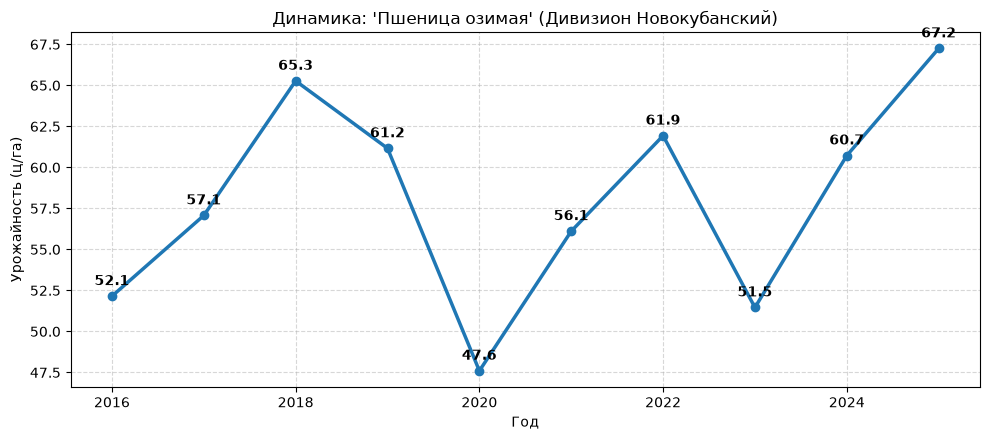

In [10]:
target_division = "Дивизион Новокубанский"
target_crop = "Пшеница озимая"

# Фильтрация дивизиону и культуре
regional_trend = (
    df_merged[
        (df_merged["division"] == target_division)
        & (df_merged["crop_name"] == target_crop)
    ]
    .groupby("year")["productivity"]
    .median()
    .reset_index()
)

# Отрисовка
plt.figure(figsize=(10, 4.5))
plt.plot(
    regional_trend["year"],
    regional_trend["productivity"],
    marker="o",
    color="#1f77b4",
    linewidth=2.5,
)

plt.title(
    f"Динамика: '{target_crop}' ({target_division})", fontsize=12
)
plt.xlabel("Год")
plt.ylabel("Урожайность (ц/га)")
plt.grid(True, linestyle="--", alpha=0.5)

for _, row in regional_trend.iterrows():
    plt.annotate(
        f"{row['productivity']:.1f}",
        (row["year"], row["productivity"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

**Промежуточный вывод**

- Из датасета df_merged (стабильные поля, больше 3-х лет истории) отфильтрованы 4 целевые культуры (без паров и пропущенных значений) и для каждой комбинации "дивизион - культура" рассчитана ежегодная медианная урожайность (ц/га). Сформировано и сохранено 19 отдельных файлов с графиками динамики.


- На графиках изображен многолетний тренд медианной урожайности конкретной культуры в рамках одного дивизиона (как в примере).


---

### Одна культура и все дивизионы

In [11]:
# Список культур
target_crops = [
    "Пшеница озимая",
    "Подсолнечник масличный",
    "Пшеница яровая мягкая",
    "Кукуруза на зерно",
]

# 1 культура, все дивизионы
output_dir_crops = "dynamics_crop"
os.makedirs(output_dir_crops, exist_ok=True)

print("Генерация графиков - по культурам")
for crop in target_crops:
    df_crop = df_merged[df_merged["crop_name"] == crop]

    if df_crop.empty:
        print(f"Предупреждение: Данные по культуре '{crop}' не найдены.")
        continue

    # годы по строкам, дивизионы по колонкам
    pivot_crop = (
        df_crop.groupby(["year", "division"])["productivity"]
        .median()
        .unstack()
    )

    fig, ax = plt.subplots(figsize=(11, 5))
    pivot_crop.plot(kind="line", marker="o", linewidth=2, ax=ax)

    ax.set_title(
        f"Динамика урожайности: {crop} (по дивизионам)", fontweight="bold"
    )
    ax.set_ylabel("Урожайность, ц/га")
    ax.set_xlabel("Год")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(title="Дивизион", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()

    # Сохранение 
    safe_filename = crop.replace(" ", "_")
    filepath = os.path.join(output_dir_crops, f"crop_{safe_filename}.png")
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close(fig) 

    print(f"Сохранен: {filepath}")

Генерация графиков - по культурам
Сохранен: dynamics_crop\crop_Пшеница_озимая.png
Сохранен: dynamics_crop\crop_Подсолнечник_масличный.png
Сохранен: dynamics_crop\crop_Пшеница_яровая_мягкая.png
Сохранен: dynamics_crop\crop_Кукуруза_на_зерно.png


#### Пример

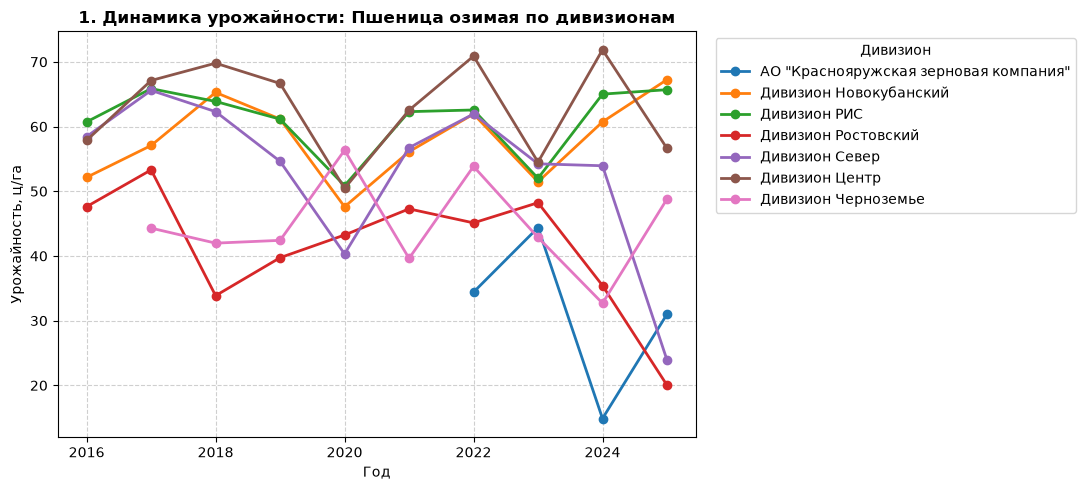

In [12]:
target_crop = "Пшеница озимая"

pivot_crop = (
    df_merged[df_merged["crop_name"] == target_crop]
    .groupby(["year", "division"])["productivity"]
    .median()
    .unstack()
)

fig, ax1 = plt.subplots(figsize=(11, 5))
pivot_crop.plot(kind="line", marker="o", linewidth=2, ax=ax1)

ax1.set_title(
    f"1. Динамика урожайности: {target_crop} по дивизионам", fontweight="bold"
)
ax1.set_ylabel("Урожайность, ц/га")
ax1.set_xlabel("Год")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend(title="Дивизион", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Промежуточный вывод**

- Для целевой группы культур построена таблица с расчетом медианной урожайности по годам со всеми доступными дивизионами. Сформировано и сохранено 4 графика в папку dynamics_crop.

- На графиках изображена динамика медианной урожайности выбранной культуры (в примере это озимой пшеница) одновременно по всем дивизионам, это позволяет сопоставить их продуктивность и региональные тренды по годам.


---

### Один дивизион и все культуры

In [13]:
output_dir_divs = "dynamics_division"
os.makedirs(output_dir_divs, exist_ok=True)

# Получаем список всех уникальных дивизионов из датасета
all_divisions = df_merged["division"].dropna().unique()

print("\nГенерация графиков - по дивизионам")
for division in all_divisions:
    # Фильтруем текущий дивизион и выбранные культуры
    df_div = df_merged[
        (df_merged["division"] == division)
        & (df_merged["crop_name"].isin(target_crops))
    ]

    if df_div.empty:
        continue

    # годы по строкам, культуры по колонкам
    pivot_div = (
        df_div.groupby(["year", "crop_name"])["productivity"]
        .median()
        .unstack()
    )

    fig, ax = plt.subplots(figsize=(11, 5))
    pivot_div.plot(kind="line", marker="s", linewidth=2, ax=ax)

    ax.set_title(
        f"Динамика урожайности: {division} (целевые культуры)",
        fontweight="bold",
    )
    ax.set_ylabel("Урожайность, ц/га")
    ax.set_xlabel("Год")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(title="Культура", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()

    # Сохранение файла
    safe_div_name = (
        str(division)
        .replace(" ", "_")
        .replace("/", "_")
        .replace('"', "")
    )
    filepath = os.path.join(output_dir_divs, f"division_{safe_div_name}.png")
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"Сохранен: {filepath}")


Генерация графиков - по дивизионам
Сохранен: dynamics_division\division_Дивизион_Новокубанский.png
Сохранен: dynamics_division\division_Дивизион_Центр.png
Сохранен: dynamics_division\division_Дивизион_Север.png
Сохранен: dynamics_division\division_Дивизион_РИС.png
Сохранен: dynamics_division\division_Дивизион_Ростовский.png
Сохранен: dynamics_division\division_Дивизион_Черноземье.png
Сохранен: dynamics_division\division_АО_Краснояружская_зерновая_компания.png


#### Пример

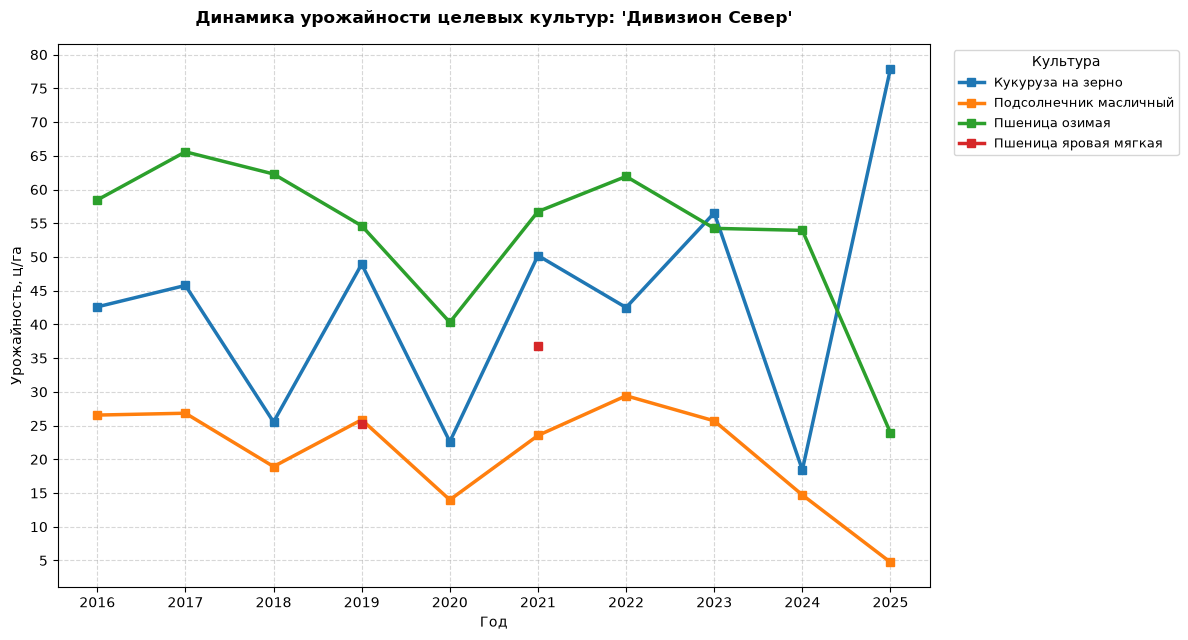

In [14]:
target_division = "Дивизион Север"

# Список целевых культур
target_crops = [
    "Пшеница озимая",
    "Подсолнечник масличный",
    "Пшеница яровая мягкая",
    "Кукуруза на зерно",
]

# Фильтр по дивизиону, целевым культурам и наличию урожайности
df_div_target = df_merged[
    (df_merged["division"] == target_division)
    & (df_merged["crop_name"].isin(target_crops))
    & (df_merged["productivity"].notna())
].copy()

# Гарантируем целочисленный тип года
df_div_target["year"] = df_div_target["year"].astype(int)

# Сводная таблица медианной урожайности
pivot_division = (
    df_div_target.groupby(["year", "crop_name"])["productivity"]
    .median()
    .unstack()
)

fig, ax2 = plt.subplots(figsize=(12, 6.5))
pivot_division.plot(kind="line", marker="s", linewidth=2.5, ax=ax2)

# Шаг оси Y каждые 5 ц/га для удобства считывания
ax2.yaxis.set_major_locator(ticker.MultipleLocator(5))

# Подписи оси X только целыми годами
if not pivot_division.empty:
    ax2.set_xticks(pivot_division.index)
    ax2.xaxis.set_major_formatter(ticker.FormatStrFormatter("%d"))

ax2.set_title(
    f"Динамика урожайности целевых культур: '{target_division}'",
    fontweight="bold",
    fontsize=12,
    pad=15,
)
ax2.set_ylabel("Урожайность, ц/га", fontsize=10)
ax2.set_xlabel("Год", fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.5)

ax2.legend(
    title="Культура",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9,
    title_fontsize=10,
)

plt.tight_layout()
plt.show()

**Промежуточный вывод**

- Для каждого дивизиона построена таблица с медианной урожайности по годам для целевых культур. Сформировано и сохранено 7 графиков (по одному на каждый дивизион) в папку dynamics_division.

- На графике видна динамика медианной урожайности целевых культур внутри конкретного дивизиона (в примере это Дивизион Север), позволяющая оценить и сопоставить продуктивность разных культур в одном регионе по годам.


---

### Столбчатый график аномалий по годам

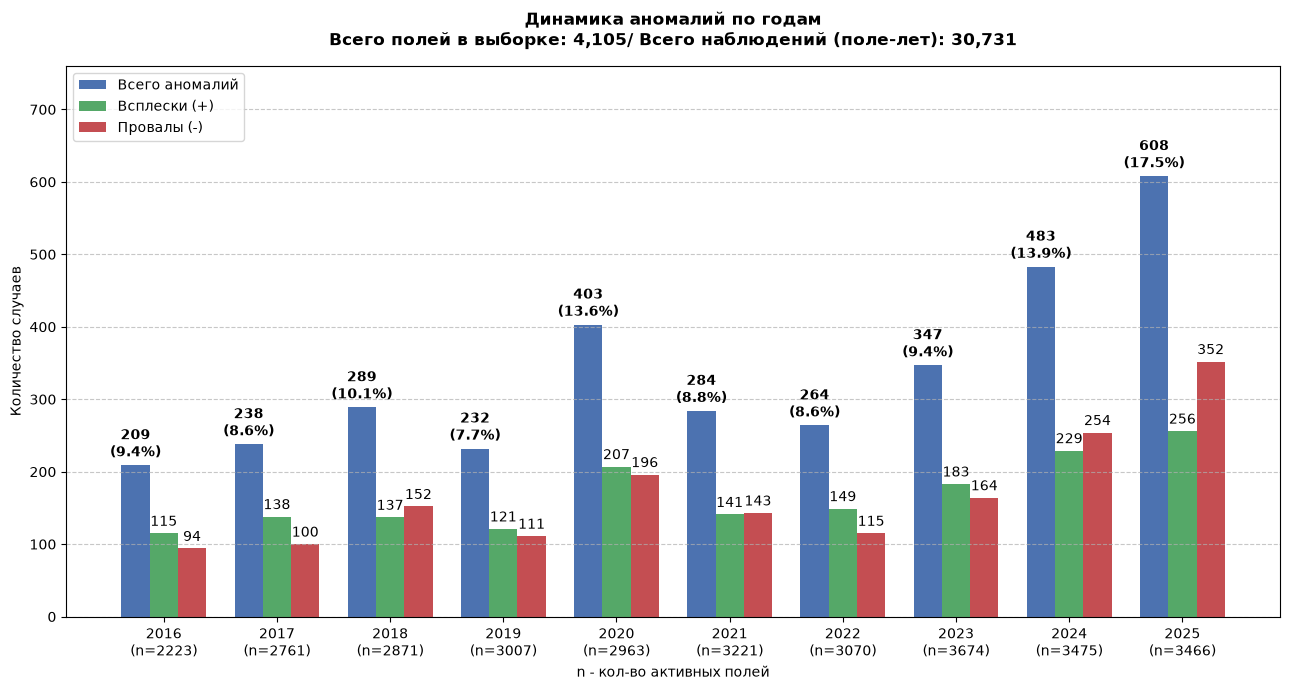

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Фильтр активных полей, без паров и пропусков)
active_records = df_merged[
    ~df_merged["anomaly_type"].isin(["Отдых (Пар)", "Нет данных"])
].copy()

# Статистика
total_unique_fields = active_records["field_id"].nunique()
total_record_count = len(active_records)

# Сводка по годам 
yearly_anomalies = (
    active_records.groupby("year")
    .agg(
        total_fields=("field_id", "count"),  
        spikes=("anomaly_type", lambda x: (x == "Всплеск (+)").sum()),
        drops=("anomaly_type", lambda x: (x == "Провал (-)").sum()),
        total=("is_anomaly", "sum"),
    )
    .reset_index()
)

# Расчет доли аномалий 
yearly_anomalies["pct_total"] = (
    yearly_anomalies["total"] / yearly_anomalies["total_fields"]
) * 100

# 4сам график
fig, ax = plt.subplots(figsize=(13, 7))

years = yearly_anomalies["year"].astype(str)
# В подписи дльавлю обьём
x_labels = [
    f"{yr}\n(n={tf})"
    for yr, tf in zip(years, yearly_anomalies["total_fields"])
]

x = np.arange(len(years))
width = 0.25

rects1 = ax.bar(
    x - width,
    yearly_anomalies["total"],
    width,
    label="Всего аномалий",
    color="#4C72B0",
)
rects2 = ax.bar(
    x,
    yearly_anomalies["spikes"],
    width,
    label="Всплески (+)",
    color="#55A868",
)
rects3 = ax.bar(
    x + width,
    yearly_anomalies["drops"],
    width,
    label="Провалы (-)",
    color="#C44E52",
)

# Оформление 
ax.set_ylabel("Количество случаев")
ax.set_title(
    f"Динамика аномалий по годам\n"
    f"Всего полей в выборке: {total_unique_fields:,}/ Всего наблюдений (поле-лет): {total_record_count:,}",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_xlabel("n - кол-во активных полей")
ax.legend(loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.7)

# Форм информативные подписи 
custom_labels_total = [
    f"{tot}\n({pct:.1f}%)"
    for tot, pct in zip(
        yearly_anomalies["total"], yearly_anomalies["pct_total"]
    )
]

# Вывод 
ax.bar_label(
    rects1, labels=custom_labels_total, padding=3, fontweight="bold"
)
ax.bar_label(rects2, padding=3)
ax.bar_label(rects3, padding=3)
ax.set_ylim(0, yearly_anomalies["total"].max() * 1.25)

plt.tight_layout()
plt.show()

**Промежуточный вывод**

- Отфильтрованы активные стабильные поля и для каждого года рассчитано кол-во полей (n), сумм. число аномалий, а также их характер.
- Построен столбчатый график (2016–2025 гг.), показывающий динамику аномалий для 4 105 полей (Стабильные и больше 3 лет истории, 30 731 наблюдение).


- Кол-во активных полей  в 2016 году (n = 2 223)  а  в период 2023–2025 гг. стабилизировалось на уровне $\sim 3 400\text{--}3 600$.

- В большинство лет (2016–2022) доля аномалий была в районе 7.7% – 10.1%. Исключением стал 2020 год, когда доля аномалий поднялась до 13.6% (403) - положительные (207) и отрицательные (196) скачки.

- Начиная с 2022 года наблюдается рост аномалий, особенно в 2024-2015 гг.
    - В 2024 году доля аномалий выросла до 13.9% (483).
    - В 2025 году достигнут пик - 17.5% (608 аномалий). 



- До 2023 года количество положительных аномалий часто превышало или было равно числу провалов, а в 2024–2025 гг. изменилось,  негативные аномалии стало больше. В 2025 году из 608 случаев 352 на провалы урожайности (58% от всех аномалий года) и 256 всплесков.


---

#### Отдельный год

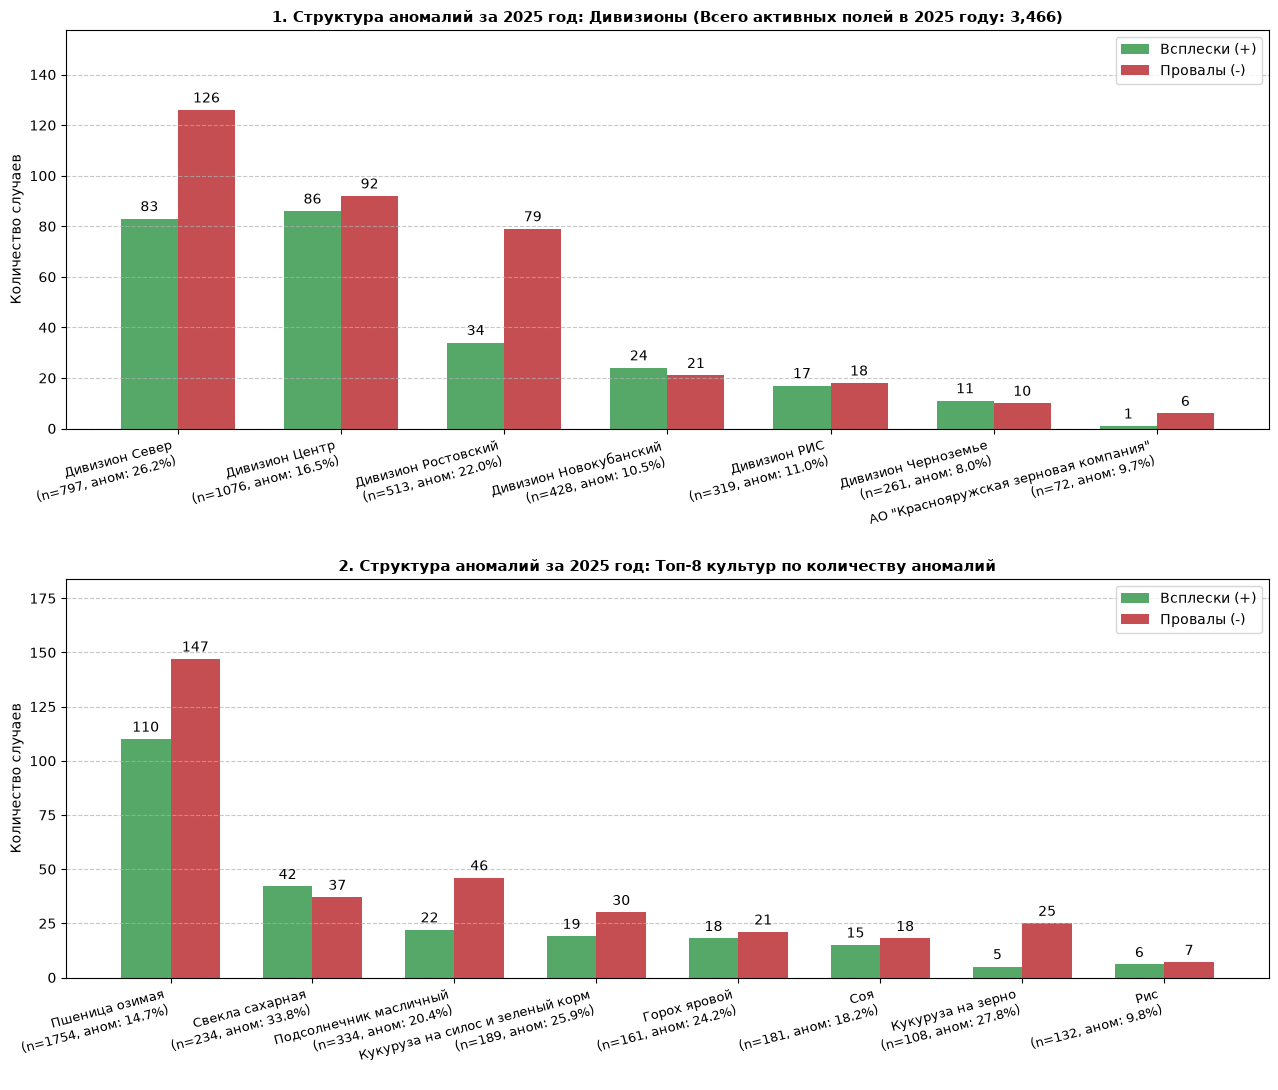

In [16]:
target_year = 2025

# Фильтр за выбранный год и общее число полей в этом году
df_year = active_records[active_records["year"] == target_year]
total_fields_year = len(df_year)

# Агрегация по дивизионам
year_by_division = (
    df_year.groupby("division")
    .agg(
        total_fields=("field_id", "count"),
        spikes=("anomaly_type", lambda x: (x == "Всплеск (+)").sum()),
        drops=("anomaly_type", lambda x: (x == "Провал (-)").sum()),
        total=("is_anomaly", "sum"),
    )
    .reset_index()
    .sort_values("total", ascending=False)
)
year_by_division["pct_anomaly"] = (
    year_by_division["total"] / year_by_division["total_fields"]
) * 100

# Агрегация по культурам 
year_by_crop = (
    df_year.groupby("crop_name")
    .agg(
        total_fields=("field_id", "count"),
        spikes=("anomaly_type", lambda x: (x == "Всплеск (+)").sum()),
        drops=("anomaly_type", lambda x: (x == "Провал (-)").sum()),
        total=("is_anomaly", "sum"),
    )
    .reset_index()
    .sort_values("total", ascending=False)
    .head(8)  # Ограничение до 8 для читаемости
)
year_by_crop["pct_anomaly"] = (
    year_by_crop["total"] / year_by_crop["total_fields"]
) * 100

# Построение 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 11))
width = 0.35

# -----------------
# 1- Дивизионы
x1 = np.arange(len(year_by_division))

rects1_1 = ax1.bar(
    x1 - width / 2,
    year_by_division["spikes"],
    width,
    label="Всплески (+)",
    color="#55A868",
)
rects1_2 = ax1.bar(
    x1 + width / 2,
    year_by_division["drops"],
    width,
    label="Провалы (-)",
    color="#C44E52",
)

# Формирование подписей оси 
div_labels = [
    f"{div}\n(n={tf}, аном: {pct:.1f}%)"
    for div, tf, pct in zip(
        year_by_division["division"],
        year_by_division["total_fields"],
        year_by_division["pct_anomaly"],
    )
]

ax1.set_ylabel("Количество случаев")
ax1.set_title(
    f"1. Структура аномалий за {target_year} год: Дивизионы (Всего активных полей в {target_year} году: {total_fields_year:,})",
    fontsize=11,
    fontweight="bold",
)
ax1.set_xticks(x1)
ax1.set_xticklabels(div_labels, rotation=15, ha="right", fontsize=9)
ax1.legend()
ax1.grid(axis="y", linestyle="--", alpha=0.7)
ax1.bar_label(rects1_1, padding=3)
ax1.bar_label(rects1_2, padding=3)

# Запас высоты оси Y для размещения меток
max_val_div = max(
    year_by_division["spikes"].max(), year_by_division["drops"].max()
)
ax1.set_ylim(0, max_val_div * 1.25)

# -----------------
# 2- Культуры
x2 = np.arange(len(year_by_crop))

rects2_1 = ax2.bar(
    x2 - width / 2,
    year_by_crop["spikes"],
    width,
    label="Всплески (+)",
    color="#55A868",
)
rects2_2 = ax2.bar(
    x2 + width / 2,
    year_by_crop["drops"],
    width,
    label="Провалы (-)",
    color="#C44E52",
)

crop_labels = [
    f"{crop}\n(n={tf}, аном: {pct:.1f}%)"
    for crop, tf, pct in zip(
        year_by_crop["crop_name"],
        year_by_crop["total_fields"],
        year_by_crop["pct_anomaly"],
    )
]

ax2.set_ylabel("Количество случаев")
ax2.set_title(
    f"2. Структура аномалий за {target_year} год: Топ-8 культур по количеству аномалий",
    fontsize=11,
    fontweight="bold",
)
ax2.set_xticks(x2)
ax2.set_xticklabels(crop_labels, rotation=15, ha="right", fontsize=9)
ax2.legend()
ax2.grid(axis="y", linestyle="--", alpha=0.7)
ax2.bar_label(rects2_1, padding=3)
ax2.bar_label(rects2_2, padding=3)

max_val_crop = max(year_by_crop["spikes"].max(), year_by_crop["drops"].max())
ax2.set_ylim(0, max_val_crop * 1.25)

plt.tight_layout()
plt.show()

**Промежуточный вывод**


- Дивизионы:
    - Соотношения провалов: Север (26.2% аномалий; 126 провалов и 83 всплеска) и Ростовский (22.0%; 79 провалов и 34 всплеска).
    - Крупнейший регион: Центр показывает 16.5% аномалий при равном балансе (86 всплесков / 92 провала).
    - Стабильные зоны: Черноземье (8.0%) и Краснояружская ЗК (9.7%).

- Культуры:
    - Пшеница озимая дает максимум аномалий (257 случаев, 14.7% от своего объема) с перевесом в сторону провалов (147).
    - Свекла сахарная (33.8% аномалий, чаще всплески) и Кукуруза на зерно (27.8%, сильный провал: 25 провалов и 5 всплесков).
    - Рис самая стабильная культура (9.8% аномалий).


---

In [17]:
# 10 самых сильных провалов
top_drops_list = (
    df_merged[df_merged["anomaly_type"] == "Провал (-)"]
    .sort_values("yield_ratio", ascending=True)
    [["field_id", "division", "crop_name", "productivity", "yield_ratio"]]
    .head(10)
)

print(f"10 полей с самыми сильными провалами в {target_year} году")
print(top_drops_list.to_string(index=False))

10 полей с самыми сильными провалами в 2025 году
field_id               division         crop_name  productivity  yield_ratio
   26467 Дивизион Новокубанский    Пшеница озимая      5.350000     0.119901
   13788 Дивизион Новокубанский    Пшеница озимая      9.060000     0.170686
   25883    Дивизион Черноземье               Соя      3.550000     0.201877
   13899 Дивизион Новокубанский    Пшеница озимая      9.120000     0.204393
   13877 Дивизион Новокубанский    Пшеница озимая     11.700000     0.214600
   13779           Дивизион РИС               Соя      2.476316     0.218837
   14032 Дивизион Новокубанский    Пшеница озимая     10.760000     0.241147
   22327         Дивизион Центр Кукуруза на зерно      7.200000     0.246660
   13909 Дивизион Новокубанский    Пшеница озимая     11.240000     0.251905
   14060 Дивизион Новокубанский    Пшеница озимая     12.290000     0.258737


### Анализ влияния предшественников

In [18]:
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 41050 entries, 0 to 41049
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   field_id          41050 non-null  str    
 1   field_name        41050 non-null  str    
 2   division          41050 non-null  str    
 3   area_ha           41050 non-null  float64
 4   year              41050 non-null  int64  
 5   crop_id           36254 non-null  float64
 6   variety           31099 non-null  str    
 7   sowing_date       30704 non-null  str    
 8   harvesting_date   3819 non-null   str    
 9   productivity      30731 non-null  float64
 10  expected_yield    320 non-null    float64
 11  is_active         41050 non-null  bool   
 12  crop_name         41050 non-null  str    
 13  yield_ratio       30730 non-null  float64
 14  prev_crop         36945 non-null  str    
 15  stability         41050 non-null  float64
 16  median_yr         41050 non-null  float64
 17  std_

📂 Медианный Barplot сохранен: plots\precursor_median_impact.png


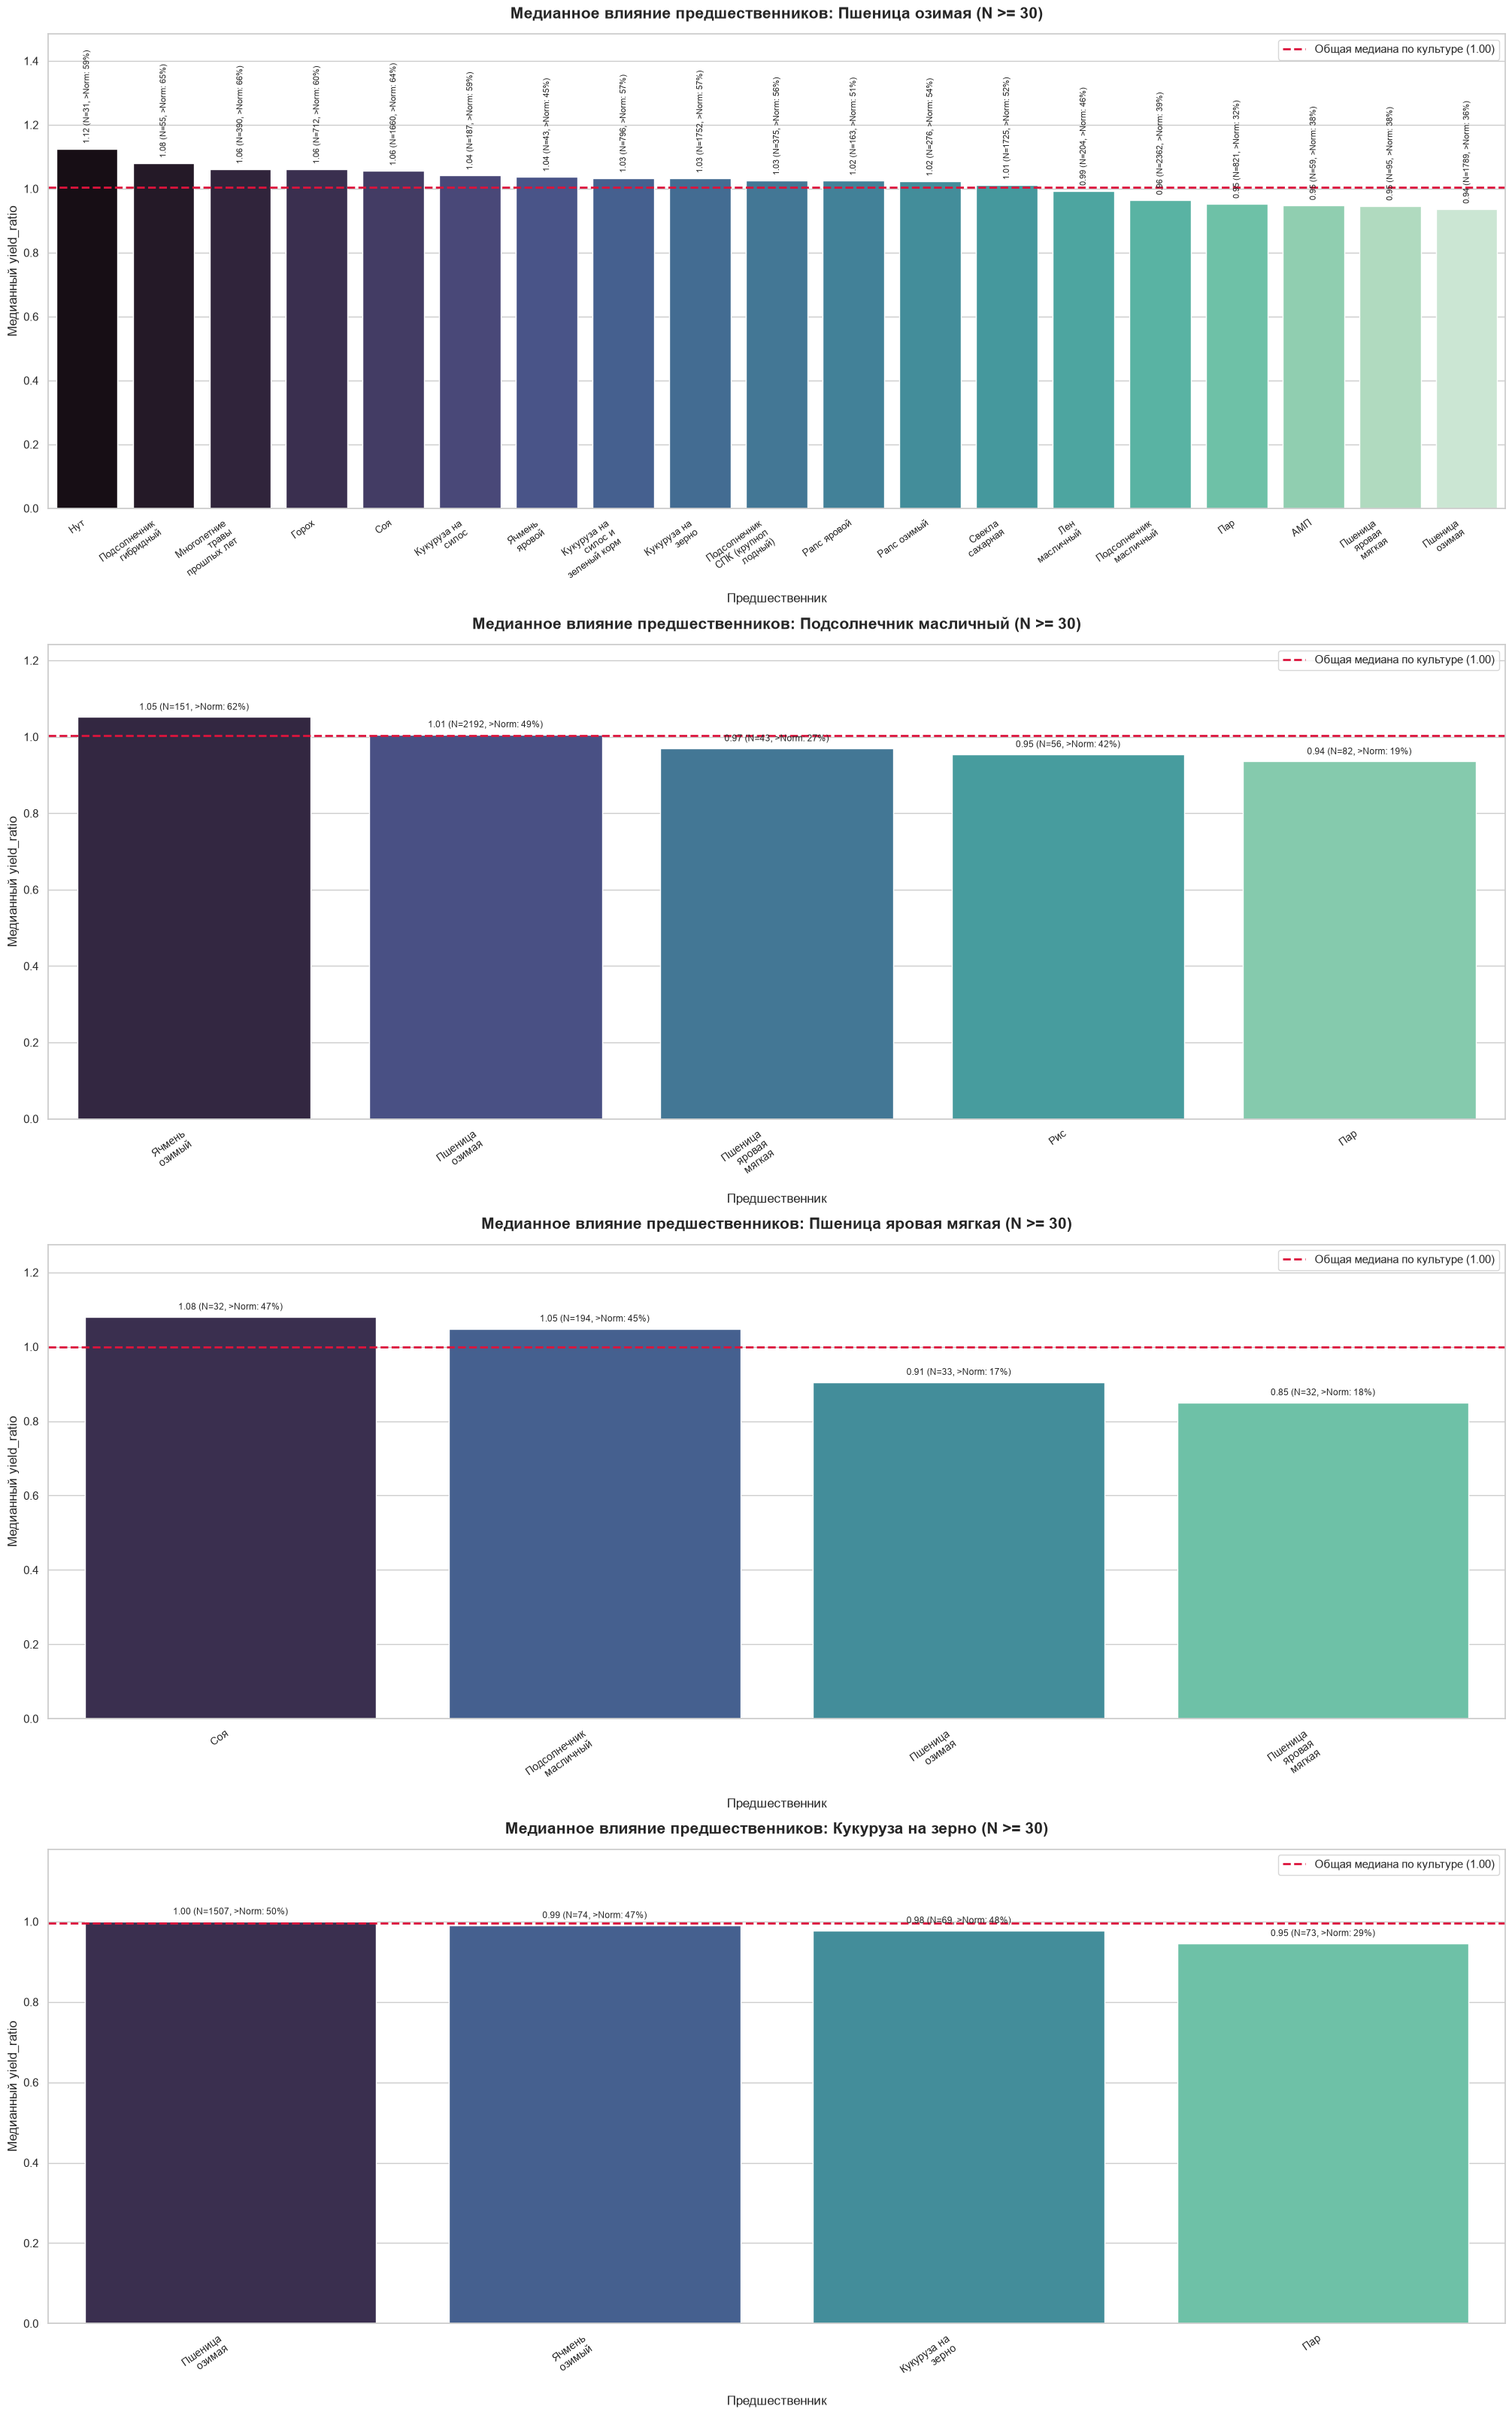

📂 Boxplot распределения сохранен: plots\precursor_boxplot_distribution.png


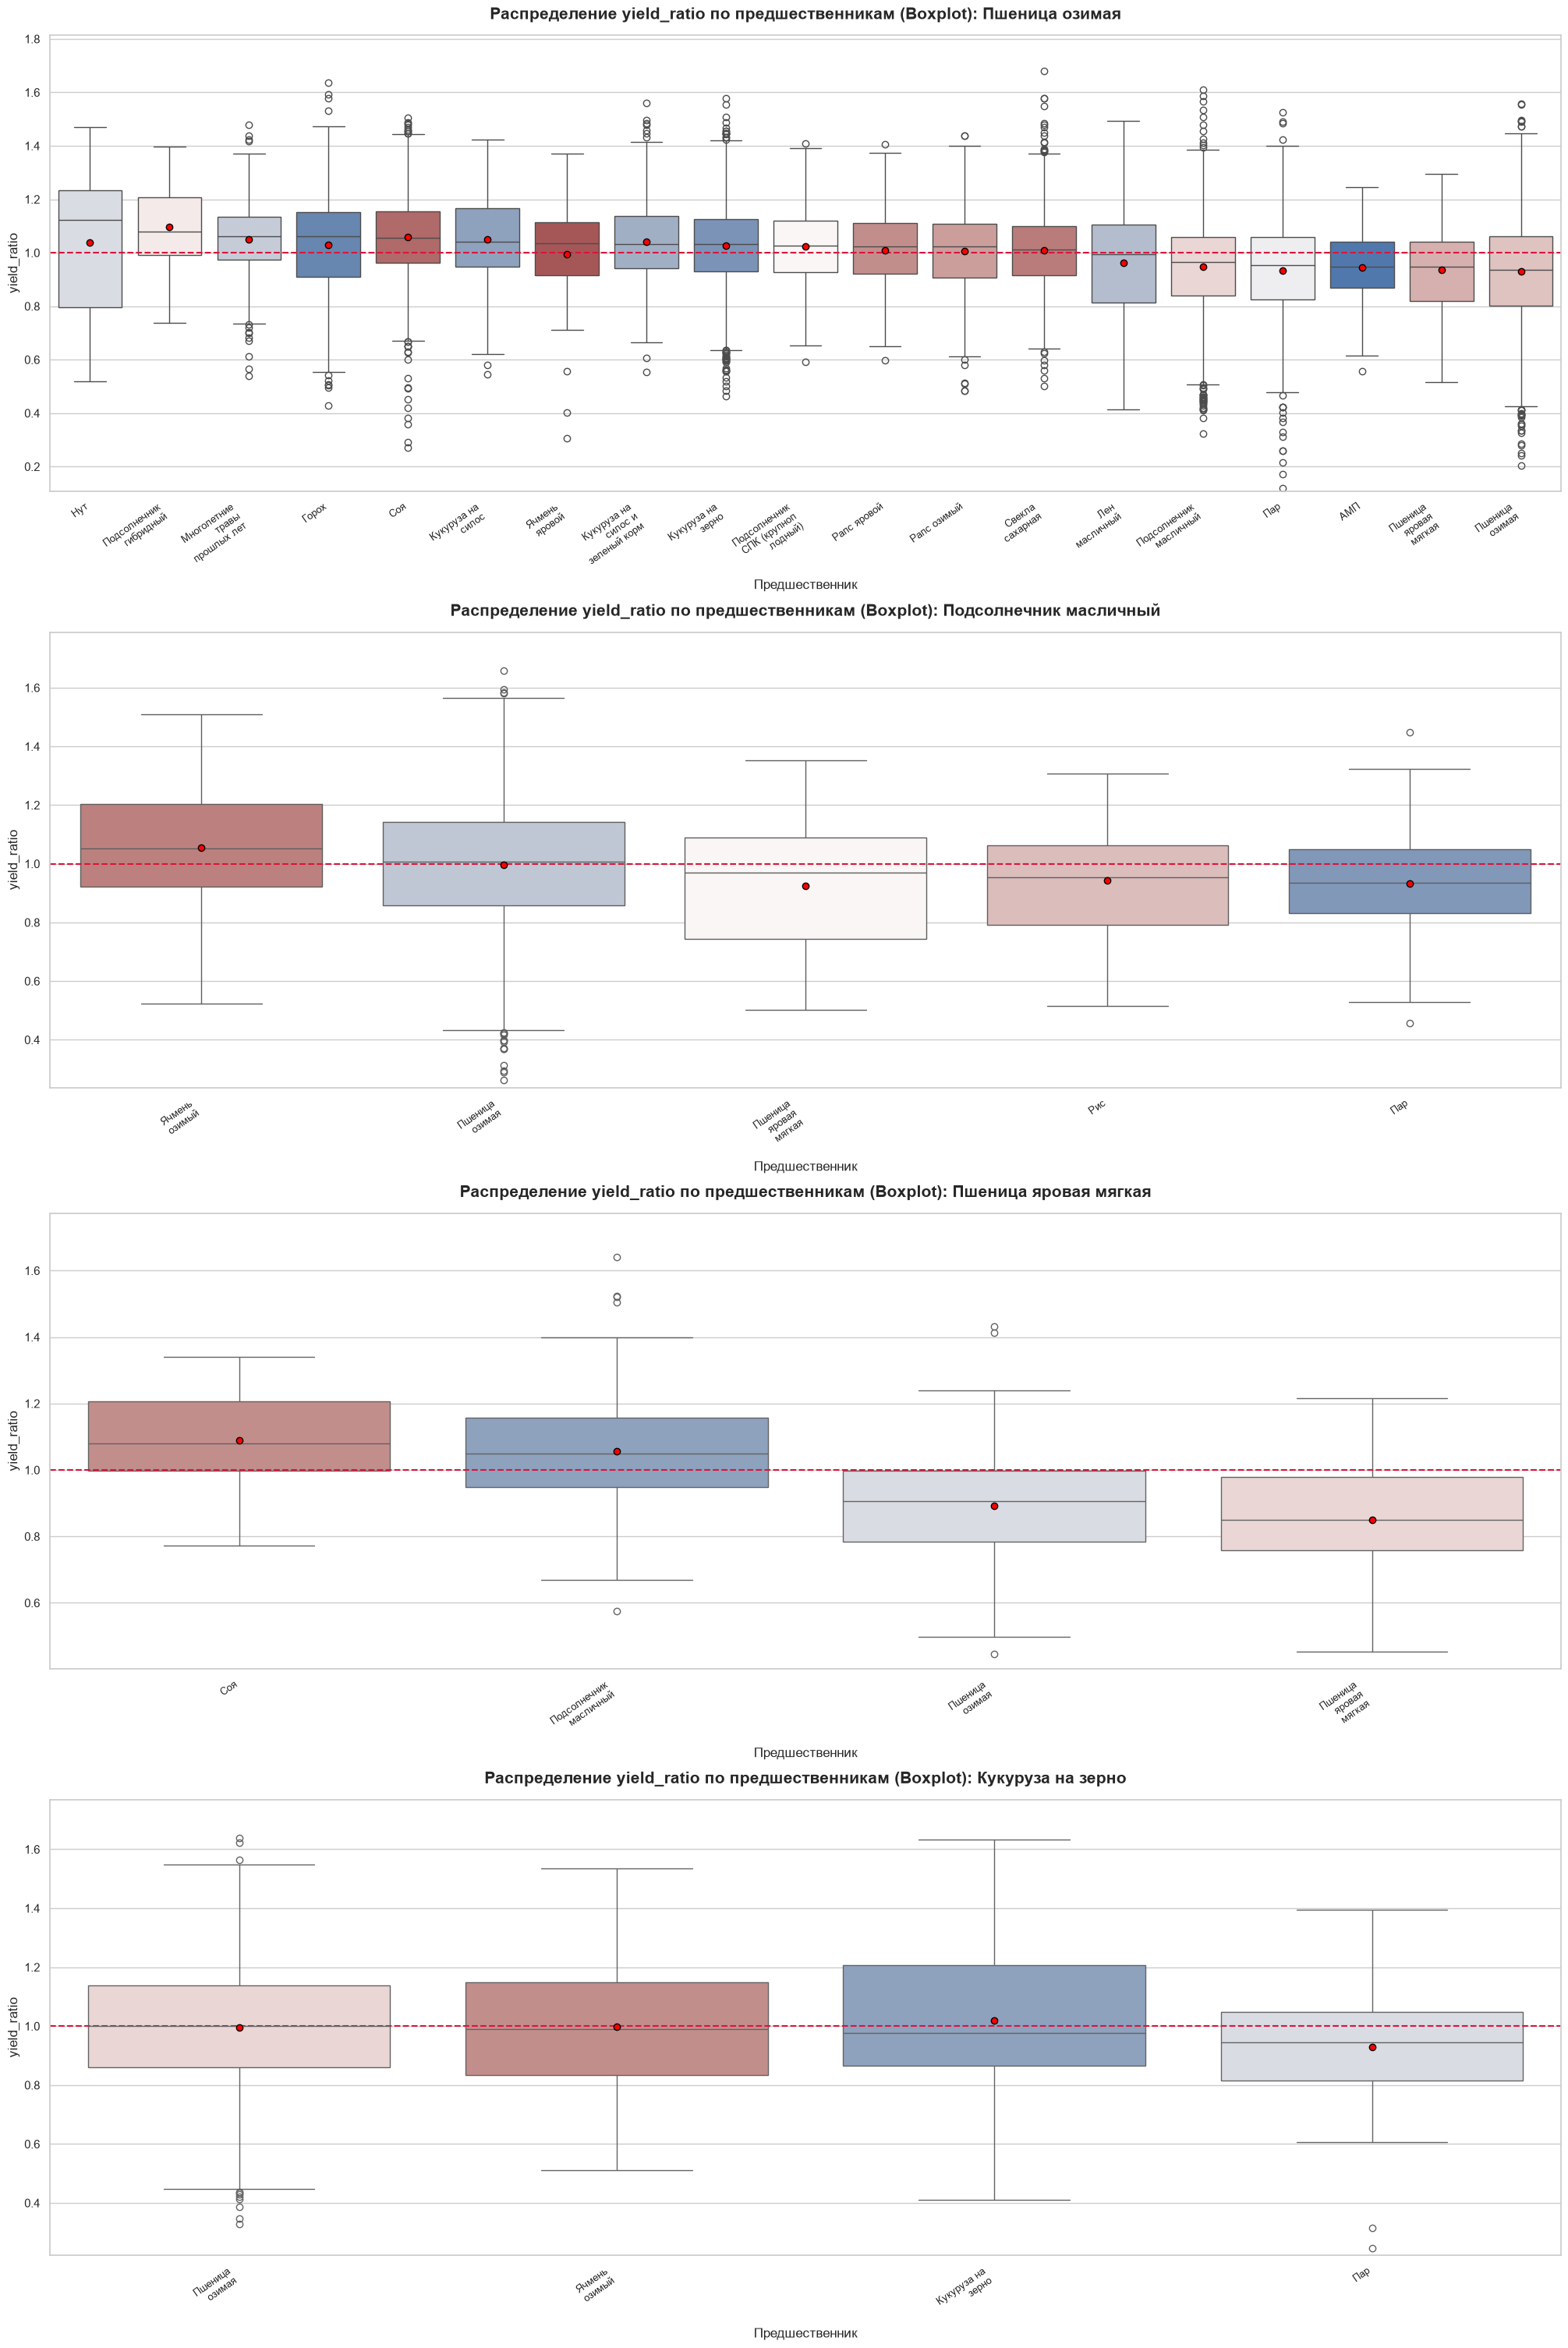

In [19]:
# --- 0. Конфигурация ---
OUTPUT_DIR = "plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CROP_COL = "crop_name"
PREV_CROP_COL = "prev_crop"
YIELD_COL = "yield_ratio"

TARGET_CROPS = [
    "Пшеница озимая",
    "Подсолнечник масличный",
    "Пшеница яровая мягкая",
    "Кукуруза на зерно",
]
MIN_SAMPLES = 30

# --- 1. Подготовка данных ---
df_work = df_merged[df_merged[CROP_COL].isin(TARGET_CROPS)].copy()

counts = df_work.groupby([CROP_COL, PREV_CROP_COL])[YIELD_COL].count()
valid_pairs = counts[counts >= MIN_SAMPLES].index

df_filtered = (
    df_work.set_index([CROP_COL, PREV_CROP_COL]).loc[valid_pairs].reset_index()
)

pred_medians = (
    df_filtered.groupby([CROP_COL, PREV_CROP_COL])[YIELD_COL]
    .agg(
        median="median",
        count="count",
        pct_above=lambda x: (x >= 1.00).mean() * 100,
    )
    .reset_index()
)
overall_medians = df_work.groupby(CROP_COL)[YIELD_COL].median().to_dict()

# --- 2. ГРАФИК 1: Медианная урожайность (Barplot) ---
sns.set_theme(style="whitegrid")

fig1, axes1 = plt.subplots(
    len(TARGET_CROPS),
    1,
    figsize=(20, 8 * len(TARGET_CROPS)),
    constrained_layout=True,
)

for idx, culture in enumerate(TARGET_CROPS):
    ax = axes1[idx] if len(TARGET_CROPS) > 1 else axes1
    sub_data = pred_medians[pred_medians[CROP_COL] == culture].sort_values(
        by="median", ascending=False
    )

    if sub_data.empty:
        ax.set_title(
            f"Культура: {culture} (нет данных с N >= {MIN_SAMPLES})",
            fontsize=12,
        )
        continue

    # Определяем плотность графика и форматируем подписи осей в 2 строки
    n_items = len(sub_data)
    is_dense = n_items > 10  # Флаг высокой плотности столбцов (для озимой пшеницы)

    sub_data = sub_data.copy()
    sub_data["prev_crop_wrapped"] = sub_data[PREV_CROP_COL].apply(
        lambda x: textwrap.fill(str(x), width=12)
    )

    bars = sns.barplot(
        data=sub_data,
        x="prev_crop_wrapped",
        y="median",
        ax=ax,
        palette="mako",
        hue="prev_crop_wrapped",
        legend=False,
    )

    benchmark = overall_medians[culture]
    ax.axhline(
        benchmark,
        color="crimson",
        linestyle="--",
        linewidth=2,
        label=f"Общая медиана по культуре ({benchmark:.2f})",
    )

    ax.set_title(
        f"Медианное влияние предшественников: {culture} (N >= {MIN_SAMPLES})",
        fontsize=15,
        fontweight="bold",
        pad=15,
    )
    ax.set_xlabel("Предшественник", fontsize=12, labelpad=10)
    ax.set_ylabel("Медианный yield_ratio", fontsize=12)

    plt.setp(
        ax.get_xticklabels(),
        rotation=35,
        ha="right",
        fontsize=9 if is_dense else 10,
    )
    ax.legend(loc="upper right", frameon=True, fontsize=11)

    # Запас высоты: увеличиваем при вертикальных подписях, чтобы текст не вылетал за границы
    max_height = sub_data["median"].max()
    ax.set_ylim(0, max_height * (1.32 if is_dense else 1.18))

    # Аннотации над столбцами: если столбцов много, текст поворачивается на 90 градусов
    for bar, (_, row) in zip(bars.patches, sub_data.iterrows()):
        height = bar.get_height()
        if not np.isnan(height):
            ax.annotate(
                f"{height:.2f} (N={int(row['count'])}, >Norm: {row['pct_above']:.0f}%)",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center" if is_dense else "center",
                va="bottom",
                fontsize=8 if is_dense else 8.5,
                rotation=90 if is_dense else 0,
                linespacing=1.1,
            )

file_path_bar = os.path.join(OUTPUT_DIR, "precursor_median_impact.png")
fig1.savefig(file_path_bar, dpi=300, bbox_inches="tight")
print(f"📂 Медианный Barplot сохранен: {file_path_bar}")
plt.show()

# --- 3. ГРАФИК 2: Дисперсия и размах (Boxplot) ---
fig2, axes2 = plt.subplots(
    len(TARGET_CROPS),
    1,
    figsize=(20, 7.5 * len(TARGET_CROPS)),
    constrained_layout=True,
)

for idx, culture in enumerate(TARGET_CROPS):
    ax = axes2[idx] if len(TARGET_CROPS) > 1 else axes2
    crop_data = df_filtered[df_filtered[CROP_COL] == culture].copy()

    # Форматирование названий осей в 2 строки без warnings
    crop_data["prev_crop_wrapped"] = crop_data[PREV_CROP_COL].apply(
        lambda x: textwrap.fill(str(x), width=12)
    )

    order = [
        textwrap.fill(str(x), width=12)
        for x in crop_data.groupby(PREV_CROP_COL)[YIELD_COL]
        .median()
        .sort_values(ascending=False)
        .index
    ]

    sns.boxplot(
        data=crop_data,
        x="prev_crop_wrapped",
        y=YIELD_COL,
        order=order,
        ax=ax,
        palette="vlag",
        hue="prev_crop_wrapped",
        legend=False,
        showmeans=True,
        meanprops={
            "marker": "o",
            "markerfacecolor": "red",
            "markeredgecolor": "black",
        },
    )

    ax.axhline(1.00, color="crimson", linestyle="--", linewidth=1.5)
    ax.set_title(
        f"Распределение yield_ratio по предшественникам (Boxplot): {culture}",
        fontsize=15,
        fontweight="bold",
        pad=15,
    )
    ax.set_xlabel("Предшественник", fontsize=12, labelpad=10)
    ax.set_ylabel("yield_ratio", fontsize=12)

    max_val = crop_data[YIELD_COL].max()
    ax.set_ylim(bottom=crop_data[YIELD_COL].min() * 0.9, top=max_val * 1.08)

    plt.setp(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9.5)

file_path_box = os.path.join(OUTPUT_DIR, "precursor_boxplot_distribution.png")
fig2.savefig(file_path_box, dpi=300, bbox_inches="tight")
print(f"📂 Boxplot распределения сохранен: {file_path_box}")
plt.show()

---

## Химия

### Загрузка и проверка структуры

In [20]:
file_path = os.path.join("data_input", "Акты архивные.xlsx")
df_chem_raw = pd.read_excel(file_path)

print("Размерность сырых данных:", df_chem_raw.shape)
print("\nКолонки и типы данных:")
print(df_chem_raw.info())

print("\nПропуски по колонкам:")
print(df_chem_raw.isna().sum())

display(df_chem_raw.head())

Размерность сырых данных: (779824, 17)

Колонки и типы данных:
<class 'pandas.DataFrame'>
RangeIndex: 779824 entries, 0 to 779823
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   ID                              779824 non-null  str           
 1   Дата                            779824 non-null  datetime64[us]
 2   Номер                           779824 non-null  str           
 3   Проведен                        779824 non-null  int64         
 4   Номенклатура ID                 779824 non-null  object        
 5   Номенклатура                    779805 non-null  str           
 6   Вид Номенклатуры                779805 non-null  str           
 7   Ед Изм                          779804 non-null  str           
 8   Количество                      779824 non-null  float64       
 9   Счет                            779806 non-null  str           
 10  Стру

,ID,Дата,Номер,Проведен,Номенклатура ID,Номенклатура,Вид Номенклатуры,Ед Изм,Количество,Счет,Структура Посевных Площадей ID,Площадь Поля,Норма Га,Вид Работ,Поле,Культура,Год
0,8000AEDD76F2710045BF1430E0475291,2021-06-09 12:00:00,АРРС-000628,1,8DB724B6FD9DDED011E4D37B9636AF36,Гумат калия Суфлер,Материалы: Удобрения на основе гуминовых кислот,л,25.200,"Удобрения, средства защиты растений и животных...",AB7188D7F6D4F45E11EAB6C44CC80D87,84.0,0.300,NaN,61-33-БКРЕ-029,Пшеница озимая,2021.0
1,8001DA7F4C74F23246DB5287E1C753AB,2021-04-01 12:00:00,АРРЗ-000131,1,AB41B0262812AB2511E962A4B1489EBD,Аммиачная селитра,Материалы: Удобрения минеральные,кг,9200.000,"Удобрения, средства защиты растений и животных...",AB7188D7F6D4F45E11EAB554C06491E7,46.0,200.000,NaN,61-30-ПОЛВ-024,Свекла сахарная,2021.0
2,8004A254B430409A4C0FF73CA4619A69,2022-04-12 12:00:00,АРРЗ-000361,1,8DB724B6FD9DDED011E4E41F45B0FF8C,"Гранат, ВДГ",Материалы: Гербициды,не исп,1.395,"Удобрения, средства защиты растений и животных...",AB8088D7F6D4F45E11EBDB6732FBAAC7,93.0,0.015,NaN,61-30-ЖУКВ-027,Ячмень озимый,2022.0
3,8005A5DF565ACE6F45F62D298F3A4D6B,2021-04-30 12:00:00,АРРД-000045,1,9FD024B6FD9DDED011E2904E4F9409AB,"Примадонна, СЭ",Материалы: Гербициды,л,58.200,"Удобрения, средства защиты растений и животных...",AB7188D7F6D4F45E11EAB6AEC6DEF590,97.0,0.600,NaN,РДРАЗ70,Ячмень озимый,2021.0
4,80090F7206237F964E4A92162F799819,2021-04-04 12:00:00,АРКК-000008,1,AB41B0262812AB2511E962A4B1489EBD,Аммиачная селитра,Материалы: Удобрения минеральные,кг,8020.000,"Удобрения, средства защиты растений и животных...",AB7188D7F6D4F45E11EAB6AC38B5F6E5,56.0,143.214,NaN,61-06-ПОЗД-030,Пшеница озимая,2021.0


### Фильтр колонок и агрегация по полям
**Так как на одно поле в течение года удобрения могли вноситься в несколько, сводим данные к уровню "одно поле - один год"**

In [21]:
# чек всех уникальных значений с количеством записей
print("Все виды номенклатуры")
display(df_chem_raw["Вид Номенклатуры"].value_counts(dropna=False).reset_index())

# чек что попадет в Удобрения, что в СЗР, а что останется вне групп
df_cats = df_chem_raw[["Вид Номенклатуры"]].drop_duplicates().dropna().copy()

df_cats["is_fert"] = df_cats["Вид Номенклатуры"].str.contains(
    "Удобрения|Микроудобрения", case=False, na=False
)
df_cats["is_prot"] = df_cats["Вид Номенклатуры"].str.contains(
    "Гербициды|Фунгициды|Инсектициды|Протравители|Десиканты|Адьюванты|Родентициды|Фумиганты|Регуляторы роста",
    case=False,
    na=False,
)

def assign_group(row):
    if row["is_fert"] and row["is_prot"]:
        return "ОБЕ ГРУППЫ (Нужна проверка)"
    if row["is_fert"]:
        return "Удобрения"
    if row["is_prot"]:
        return "Средства защиты (СЗР)"
    return "ПРОЧЕЕ (Не попадет никуда)"

df_cats["Итоговая группа"] = df_cats.apply(assign_group, axis=1)

print("\nКатегории")
display(df_cats[["Вид Номенклатуры", "Итоговая группа"]].sort_values(by="Итоговая группа"))

Все виды номенклатуры


,Вид Номенклатуры,count
0,Материалы: Гербициды,177537
1,Материалы: Удобрения минеральные,171046
2,Материалы: Инсектициды и акарициды,103897
3,Материалы: Фунгициды,79300
4,"Материалы: Микроудобрения, стимуляторы",66095
5,Материалы: Удобрения на основе гуминовых кислот,60124
6,Материалы: Родентициды,41896
7,Материалы: Адьюванты,36183
8,Материалы: Удобрения комплексные с микроэлемен...,21454
9,Материалы: Регуляторы роста растений,7321



Категории


,Вид Номенклатуры,Итоговая группа
370,Материалы: Прочие материалы,ПРОЧЕЕ (Не попадет никуда)
6733,Материалы: Прочие средства защиты растений,ПРОЧЕЕ (Не попадет никуда)
16312,Сырье,ПРОЧЕЕ (Не попадет никуда)
56387,Материалы: Дезсредства,ПРОЧЕЕ (Не попадет никуда)
56390,Материалы: Инструменты и материалы,ПРОЧЕЕ (Не попадет никуда)
166740,Материалы: Инвентарь и хозяйст-ные принадлежности,ПРОЧЕЕ (Не попадет никуда)
206178,Материалы: Запасные части,ПРОЧЕЕ (Не попадет никуда)
241764,Материалы: Мелиоранты почвы известковые,ПРОЧЕЕ (Не попадет никуда)
342132,Готовая продукция - 10.17,ПРОЧЕЕ (Не попадет никуда)
370052,Товар,ПРОЧЕЕ (Не попадет никуда)


In [ ]:
MAIN_FIELD_COL = "field_name"

# Оставляем только нужные колонки
cols_to_keep = [
    "Поле",
    "Год",
    "Дата",
    "Номенклатура",
    "Вид Номенклатуры",
    "Норма Га",
]
df_chem = df_chem_raw[cols_to_keep].copy()

# Приводим год к числовому формату
year_numeric = pd.to_numeric(df_chem["Год"], errors="coerce")
year_from_date = pd.to_datetime(df_chem["Дата"], errors="coerce").dt.year
df_chem["year"] = year_numeric.fillna(year_from_date)

# Очищаем ключи
df_chem = df_chem.dropna(subset=["Поле", "year"]).copy()
df_chem["field_name_clean"] = (
    df_chem["Поле"].astype(str).str.strip().str.upper()
)
df_chem["year"] = df_chem["year"].astype(int)

# Размечаем Удобрения и СЗР с полным охватом подстрок
is_fert = df_chem["Вид Номенклатуры"].str.contains(
    "Удобрен|Микроудобрен", case=False, na=False
)
is_prot = df_chem["Вид Номенклатуры"].str.contains(
    "Гербицид|Фунгицид|Инсектицид|Протравител|Десикант|Адьювант|Адъювант|Родентицид|Фумигант|Регулятор|Защит",
    case=False,
    na=False,
)

df_chem["is_fertilizer"] = is_fert.astype(int)
df_chem["is_protection"] = is_prot.astype(int)

# Подготовка временных колонок для раздельного подсчета
df_chem["fert_norma"] = df_chem["Норма Га"].where(is_fert, 0)
df_chem["prot_norma"] = df_chem["Норма Га"].where(is_prot, 0)
df_chem["fert_name"] = df_chem["Номенклатура"].where(is_fert, np.nan)
df_chem["prot_name"] = df_chem["Номенклатура"].where(is_prot, np.nan)

# Агрегация до уровня "одно поле - один год"
df_chem_agg = (
    df_chem.groupby(["field_name_clean", "year"])
    .agg(
        # Блок Удобрений
        has_fertilizer=("is_fertilizer", "max"),
        fert_norma_ha=("fert_norma", "sum"),
        fert_count=("fert_name", "nunique"),
        fertilizers_list=(
            "fert_name",
            lambda x: ", ".join(sorted(x.dropna().astype(str).unique()))
            if x.dropna().nunique() > 0
            else "—",
        ),
        # Блок Защиты (СЗР)
        has_protection=("is_protection", "max"),
        prot_norma_ha=("prot_norma", "sum"),
        prot_count=("prot_name", "nunique"),
        protection_list=(
            "prot_name",
            lambda x: ", ".join(sorted(x.dropna().astype(str).unique()))
            if x.dropna().nunique() > 0
            else "—",
        ),
    )
    .reset_index()
)

print(f"Всего записей: {len(df_chem):,}")
print(f"Пар [поле-год]: {len(df_chem_agg):,}")

### Объединение

In [ ]:
# Приводим ключи к единому регистру
for df in [df_clean, df_merged]:
    df[MAIN_FIELD_COL] = (
        df[MAIN_FIELD_COL].astype(str).str.strip().str.upper()
    )
    df["year"] = df["year"].astype(int)

# Объединяем
df_clean_study = df_clean.merge(
    df_chem_agg,
    left_on=[MAIN_FIELD_COL, "year"],
    right_on=["field_name_clean", "year"],
    how="left",
)

df_merged_study = df_merged.merge(
    df_chem_agg,
    left_on=[MAIN_FIELD_COL, "year"],
    right_on=["field_name_clean", "year"],
    how="left",
)

# Заполняем пропуски для необработанных полей
for df in [df_clean_study, df_merged_study]:
    # Удобрения
    df["has_fertilizer"] = df["has_fertilizer"].fillna(0).astype(int)
    df["fert_norma_ha"] = df["fert_norma_ha"].fillna(0)
    df["fert_count"] = df["fert_count"].fillna(0).astype(int)
    df["fertilizers_list"] = (
        df["fertilizers_list"].replace("", "—").fillna("—")
    )

    # СЗр
    df["has_protection"] = df["has_protection"].fillna(0).astype(int)
    df["prot_norma_ha"] = df["prot_norma_ha"].fillna(0)
    df["prot_count"] = df["prot_count"].fillna(0).astype(int)
    df["protection_list"] = df["protection_list"].replace("", "—").fillna("—")

# Удаляем тех колонку
df_clean_study.drop(
    columns=["field_name_clean"], inplace=True, errors="ignore"
)
df_merged_study.drop(
    columns=["field_name_clean"], inplace=True, errors="ignore"
)

print('готово')

### Проверка бъединения

In [ ]:
def print_merge_stats(df_result, df_name):
    total_rows = len(df_result)
    matched_fert = (df_result["has_fertilizer"] == 1).sum()
    matched_prot = (df_result["has_protection"] == 1).sum()

    pct_fert = (matched_fert / total_rows) * 100 if total_rows > 0 else 0
    pct_prot = (matched_prot / total_rows) * 100 if total_rows > 0 else 0

    print(f"Статистика: {df_name}")
    print(f"Всего строк: {total_rows:,}")
    print(f"С удобрениями: {matched_fert:,} ({pct_fert:.2f}%)")
    print(f"Со средствами защиты (СЗР): {matched_prot:,} ({pct_prot:.2f}%)\n")


def validate_dataset_structures(
    df_clean_raw,
    df_merged_raw,
    df_chem_agg_data,
    df_clean_res,
    df_merged_res,
    field_col,
):
    print("Проверка ключей")
    clean_dups = df_clean_raw.duplicated(subset=[field_col, "year"]).sum()
    merged_dups = df_merged_raw.duplicated(subset=[field_col, "year"]).sum()
    chem_dups = df_chem_agg_data.duplicated(
        subset=["field_name_clean", "year"]
    ).sum()

    print(f"Дубликаты [поле, год] в df_clean: {clean_dups}")
    print(f"Дубликаты [поле, год] в df_merged: {merged_dups}")
    print(f"Дубликаты [поле, год] в df_chem_agg: {chem_dups}\n")

    print("Проверка сохранения объема")
    clean_len_match = len(df_clean_raw) == len(df_clean_res)
    merged_len_match = len(df_merged_raw) == len(df_merged_res)
    print(
        f"df_clean: {len(df_clean_raw):,} -> {len(df_clean_res):,}. Сохранено: {clean_len_match}"
    )
    print(
        f"df_merged: {len(df_merged_raw):,} -> {len(df_merged_res):,}. Сохранено: {merged_len_match}\n"
    )

    print("Удобрения по годам (df_clean_study)")
    year_coverage = pd.crosstab(
        df_clean_res["year"],
        df_clean_res["has_fertilizer"],
        normalize="index",
    )[1].map("{:.1%}".format)
    print(year_coverage.to_string())
    print()


# Статистика
print_merge_stats(df_clean_study, "df_clean_study (Полный датасет)")
print_merge_stats(df_merged_study, "df_merged_study (Стаб и больше 3 лет)")

# Запуск валидации 
validate_dataset_structures(
    df_clean,
    df_merged,
    df_chem_agg,
    df_clean_study,
    df_merged_study,
    MAIN_FIELD_COL,
)

#### Чекну год

In [ ]:
# в Excel по годам
print("записи в Excel по годам")
print(df_chem_raw["Год"].value_counts().dropna().sort_index())

# Уникальные категории 'Вид Номенклатуры' за 2016–2018 года
print("\nКатегории номенклатуры в Excel за 2016-2018 гг")
mask_early = df_chem_raw["Год"].isin([2016, 2017, 2018])
print(df_chem_raw[mask_early]["Вид Номенклатуры"].value_counts(dropna=False))

# Чек совпадения названий полей с df_clean за ранние года
print("\nСовпадение имен полей с df_clean по годам")
clean_fields = set(
    df_clean["field_name"].astype(str).str.strip().str.upper().unique()
)

for yr in [2016, 2017, 2018, 2019]:
    df_yr = df_chem_raw[df_chem_raw["Год"] == yr]
    raw_fields = set(
        df_yr["Поле"].astype(str).str.strip().str.upper().unique()
    )
    matched = raw_fields.intersection(clean_fields)
    print(
        f"Год {yr}: полей в Excel = {len(raw_fields)} | Совпало с df_clean = {len(matched)}"
    )

### Проверка результатов

In [ ]:
# Удаление лишних колонок
cols_to_drop = ["field_id", "crop_id", "sowing_date", "harvesting_date", "variety", "expected_yield", "diff_yield_ratio", "std_yr"]
df_clean_study.drop(columns=cols_to_drop, inplace=True, errors="ignore")
df_merged_study.drop(columns=cols_to_drop, inplace=True, errors="ignore")

# пороги 99-го процентиля
Q99_FERT = 755.00
Q99_PROT = 24.98

# выборкам
for df in [df_clean_study, df_merged_study]:
    df["fert_norma_ha"] = df["fert_norma_ha"].clip(upper=Q99_FERT)
    df["prot_norma_ha"] = df["prot_norma_ha"].clip(upper=Q99_PROT)

# Проверка распределения 
print("Распределение норм после ограничения 99-м процентилем:")
display(df_merged_study[["fert_norma_ha", "prot_norma_ha"]].describe().T)

# Колонки отображения
cols_to_display = [
    MAIN_FIELD_COL,
    "year",
    "crop_name",
    "productivity",
    "has_fertilizer",
    "fert_norma_ha",
    "fertilizers_list",
    "has_protection",
    "prot_norma_ha",
    "protection_list",
]

print("Пример строк с одновременным наличием Удобрений и СЗР (df_merged_study):")
display(
    df_merged_study[
        (df_merged_study["has_fertilizer"] == 1)
        & (df_merged_study["has_protection"] == 1)
    ][cols_to_display].head()
)

print(
    f"\nИтоговый размер df_clean_study: {df_clean_study.shape} ({len(df_clean_study.columns)} колонок)"
)
print(
    f"Итоговый размер df_merged_study: {df_merged_study.shape} ({len(df_merged_study.columns)} колонок)"
)

#### Добавлю классы полей полей 

In [ ]:
# костыль
for col in ["yield_class", "stability_class"]:
    if col in df_clean_study.columns:
        df_clean_study.drop(columns=[col], inplace=True)
    if col in df_merged_study.columns:
        df_merged_study.drop(columns=[col], inplace=True)

# нужные колонки
meta_cols = [
    "Название поля",
    "Категория урожайности (Правила)",
    "Категория стабильности",  
]

df_meta = df_excel[meta_cols].copy()
df_meta.columns = ["field_name", "yield_class", "stability_class"]

# Очистка ключа и удаление дубликатов полей 
df_meta["field_name"] = (
    df_meta["field_name"].astype(str).str.strip().str.upper()
)
df_meta_clean = df_meta.drop_duplicates(subset=["field_name"])

# Объединение
df_clean_study = df_clean_study.merge(
    df_meta_clean, on="field_name", how="left"
)
df_merged_study = df_merged_study.merge(
    df_meta_clean, on="field_name", how="left"
)

df_clean_study["stability_class"] = df_clean_study["stability_class"].fillna(
    "Нет данных"
)
df_clean_study["yield_class"] = df_clean_study["yield_class"].fillna(
    "Нет данных"
)

# ДПроверка
unique_fields_study = df_merged_study.drop_duplicates(subset=["field_name"])

print("Исходный Exels")
print(
    df_excel["Категория стабильности"].value_counts(dropna=False)
)

print(
    f"\nПо полям (всего: {unique_fields_study['field_name'].nunique()})"
)
print("\nКатегория урожайности (поля):")
print(unique_fields_study["yield_class"].value_counts(dropna=False))

print("\nКатегория стабильности (поля):")
print(unique_fields_study["stability_class"].value_counts(dropna=False))

#### Проверка

In [ ]:
print(f"Размерность df_clean_study: {df_clean_study.shape}")
df_clean_study.info()

n_unique_fields = df_merged_study["field_name"].nunique()
total_rows = len(df_merged_study)

print(f"Уникальных полей: {n_unique_fields:,}")
print(f"Всего записей [поле-год]: {total_rows:,}")

display(df_clean_study.describe().T)

display(df_clean_study.sample(5, random_state=42))

In [ ]:
print(f"Размерность df_merged_stud: {df_merged_study.shape}")
df_merged_study.info()

display(df_merged_study.describe().T)

display(df_merged_study.sample(5, random_state=42))

---

### **Промежуточный вывод**

### Очистка и категоризация
Из исходных данных в **779 тыс.** записей убран мусор. Оставшиеся агрох. препараты были разделены на два класса:

- **Удобрения**: минеральные, органические, микроудобрения, гуматы.  
- **СЗР (Защита)**: гербициды, фунгициды, инсектициды, десиканты и прочие препараты.

### Агрегация
Так как, за год одно поле может обрабатываться несколько разными препаратами, данные сгруппированны `[Поле, Год]`, получилось **64 543** записей - паспорт обработок для каждого поля за конкретный год.

### Соединение
Данные соед. к датасетам урожайности (`df_clean` и `df_merged`).

### Обработка пропусков
Полям, для которых в архиве не нашлось записей, стоит:
- нули (`0`) в числовых признаках (нормы и количества);
- прочерки (`'—'`) в текстовых списках препаратов,  

---

### Подробное признаков 

`df_merged_study` состоит из **22 колонок**.

#### Характеристики поля 

| Признак | Тип | Описание |
|---------|-----|----------|
| `field_name` | `str` | Название поля. Ключ для объединения. |
| `division` | `str` | Дивизион поля. |
| `area_ha` | `float` | Площадь поля. |
| `year` | `int` | Год записи. |
| `is_active` | `bool` | Статус поля (`True` — активно используется, `False` - выведено из оборота). |

- yield_class и stability_class: класс урожайности и стабильности

#### Агрономия и урожайность

| Признак | Тип | Описание |
|---------|-----|----------|
| `crop_name` | `str` | Название культуры. |
| `prev_crop` | `str` | Предшествующая культура. |
| `productivity` | `float` | Урожайность в ц/га. |

#### Статистика и аномалии

| Признак | Тип | Описание |
|---------|-----|----------|
| `yield_ratio` | `float` | Индекс урожайности. |
| `stability` | `float` | Коэффициент стабильности поля по годам. |
| `median_yr` | `float` | Медианный показатель `yield_ratio` для конкретной культуры по всему кластеру/дивизиону. |
| `dev_pct` | `float` | Процентное отклонение урожайности поля от нормы. |
| `anomaly_type` | `str` | Маркер выброса. |
| `is_anomaly` | `bool` | Флаг аномалии. |

#### Агрохимия: Удобрения 

| Признак | Тип | Описание |
|---------|-----|----------|
| `has_fertilizer` | `int` (0/1) | Бинарный флаг наличия удобрения. |
| `fert_norma_ha` | `float` | Суммарная норма внесения всех удобрений на гектар. Рассчитывается как сумма (`sum()`) значений колонки "Норма Га" для всех актов, попавших в группу удобрений на данном поле в этот год. |
| `fert_count` | `int` | Разнообразие питания. Количество уникальных наименований удобрений, применённых на поле за год. |
| `fertilizers_list` | `str` | Текстовый перечень всех уникальных названий удобрений, внесённых на поле. При отсутствии удобрений стоит `'—'`. |

#### Агрохимия: СЗР)


| Признак | Тип | Описание |
|---------|-----|----------|
| `has_protection` | `int` (0/1) | Бинарный флаг защиты. |
| `prot_norma_ha` | `float` | Суммарная норма внесения всех препаратов СЗР (в л/га или кг/га). Вычисляется как сумма (`sum()`) по колонке "Норма Га" для всех защитных препаратов на этом поле за год. |
| `prot_count` | `int` | Количество уникальных наименований препаратов, применённых за год. |
| `protection_list` | `str` | Текстовый перечень всех средств защиты, применённых на поле. При отсутствии стоит `'—'`. |

---

### Анализ химии